# Segmentasi Pelanggan Digital Marketing Menggunakan K-means-QLDE + Decision Tree

---

### Referensi Paper
> **Wang, G. (2025).** *Customer segmentation in the digital marketing using a Q-learning based differential evolution algorithm integrated with K-means clustering.* PLOS ONE.

Notebook ini menyesuaikan alur eksperimen paper:
1. Load dataset transaksi e-commerce
2. Feature engineering 11 fitur pelanggan (Var1-Var11)
3. Z-score normalization
4. PCA: 11 fitur -> 6 komponen utama
5. Penentuan K dengan Elbow Method
6. **K-means-QLDE**: Q-learning + Differential Evolution untuk optimasi centroid/SSE K-Means
7. Validasi label cluster menggunakan **Decision Tree** saja

> Catatan: paper memakai 4 classifier (KSVM, DT, AdaBoost, ANN), tetapi notebook ini sengaja membatasi validasi classifier ke **Decision Tree** sesuai kebutuhan tugas.


---
## Bagian 1 - Import Library & Konfigurasi Lingkungan

Langkah pertama adalah mengimpor seluruh library Python yang dibutuhkan sepanjang eksperimen ini. Berikut penjelasan masing-masing library:

- **`pandas` & `numpy`** - Manipulasi dan komputasi data tabular
- **`matplotlib` & `seaborn`** - Visualisasi grafik dan heatmap
- **`sklearn`** - Preprocessing (StandardScaler), PCA, K-Means, dan evaluasi model
- **`ucimlrepo`** - Mengunduh dataset langsung dari repositori UCI Machine Learning
- **`warnings`** - Menyembunyikan pesan peringatan yang tidak relevan

In [1]:
!pip install ucimlrepo -q

In [2]:
# ============================================================
#  BAGIAN 1 - Import Library & Konfigurasi Lingkungan
# ============================================================

# Manipulasi data
import pandas as pd
import numpy as np

# Visualisasi
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

# - Preprocessing & Reduksi Dimensi
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# Utilitas
import warnings
warnings.filterwarnings('ignore')

# Unduh dataset UCI
from ucimlrepo import fetch_ucirepo

# -----------------------------------------------------------
# Konfigurasi tampilan & reproducibility
# -----------------------------------------------------------
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

pd.set_option('display.max_columns', 20)
pd.set_option('display.float_format', '{:.4f}'.format)

plt.rcParams.update({
  'figure.dpi'  : 120,
  'axes.titlesize'  : 13,
  'axes.labelsize'  : 11,
  'xtick.labelsize' : 9,
  'ytick.labelsize' : 9,
  'font.family'  : 'sans-serif',
})

print(' Seluruh library berhasil diimpor.')
print(f'  NumPy  versi : {np.__version__}')
print(f'  Pandas versi : {pd.__version__}')

 Seluruh library berhasil diimpor.
  NumPy  versi : 2.0.2
  Pandas versi : 2.2.2


---
## Bagian 2 - Load Dataset UCI Online Retail

### Tentang Dataset
Dataset yang digunakan adalah **UCI Online Retail Dataset**. Dataset ini memiliki struktur transaksi e-commerce yang sama dengan data retail pada paper, tetapi sumber notebook adalah **UCI Machine Learning Repository (ID: 352)**, sedangkan paper merujuk dataset Kaggle/Zenodo. Karena itu, klaim kesamaan data harus dibaca sebagai **asumsi ekuivalensi dataset**, bukan bukti bahwa file sumbernya identik.

Dataset berisi data transaksi e-commerce dari toko retail berbasis UK selama periode **01 Desember 2010 - 09 Desember 2011**.

| Atribut | Detail |
|---------|--------|
| Sumber notebook | UCI Machine Learning Repository (ID: 352) |
| Sumber paper | Kaggle/Zenodo customer segmentation dataset |
| Jumlah Record | sekitar 541.909 transaksi |
| Jumlah Fitur | 8 fitur |
| Jenis Data | Multivariate, Time-Series |

**Deskripsi 8 Fitur Asal:**

| Fitur | Tipe | Keterangan |
|-------|------|------------|
| `InvoiceNo` | String | Nomor invoice transaksi |
| `StockCode` | String | Kode produk |
| `Description` | String | Nama/deskripsi produk |
| `Quantity` | Integer | Jumlah unit yang dibeli |
| `InvoiceDate` | DateTime | Tanggal dan waktu transaksi |
| `UnitPrice` | Float | Harga per unit produk |
| `CustomerID` | Float | ID unik pelanggan |
| `Country` | String | Negara pelanggan |

In [3]:
# ============================================================
#  Bagian 2 - Load Dataset
# ============================================================

print(' Mengunduh dataset dari UCI ML Repository...')
retail_repo = fetch_ucirepo(id=352)  # UCI Online Retail (id=352)

# Gabungkan fitur + target menjadi satu DataFrame
df_raw = retail_repo.data.original.copy()

print(f' Dataset berhasil dimuat.')
print(f'  Ukuran awal : {df_raw.shape[0]:,} baris  {df_raw.shape[1]} kolom')

 Mengunduh dataset dari UCI ML Repository...
 Dataset berhasil dimuat.
  Ukuran awal : 541,909 baris  8 kolom


In [4]:
# -----------------------------------------------------------
# Tampilkan 5 baris pertama
# -----------------------------------------------------------
print(' Preview 5 baris pertama dataset:')
df_raw.head()

 Preview 5 baris pertama dataset:


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.5500,17850.0000,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.3900,17850.0000,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.7500,17850.0000,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.3900,17850.0000,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.3900,17850.0000,United Kingdom


In [5]:
# -----------------------------------------------------------
# Informasi tipe data & missing values
# -----------------------------------------------------------
print(' Informasi tipe data setiap kolom:')
print(df_raw.dtypes.to_string())
print()

missing = df_raw.isnull().sum()
missing_pct = (missing / len(df_raw) * 100).round(2)
missing_info = pd.DataFrame({'Missing Count': missing, 'Missing (%)': missing_pct})
missing_info = missing_info[missing_info['Missing Count'] > 0]

print(' Kolom dengan nilai kosong (missing values):')
print(missing_info.to_string())

 Informasi tipe data setiap kolom:
InvoiceNo       object
StockCode       object
Description     object
Quantity         int64
InvoiceDate     object
UnitPrice      float64
CustomerID     float64
Country         object

 Kolom dengan nilai kosong (missing values):
             Missing Count  Missing (%)
Description           1454       0.2700
CustomerID          135080      24.9300


In [6]:
# -----------------------------------------------------------
# Statistik deskriptif
# -----------------------------------------------------------
print(' Statistik deskriptif kolom numerik:')
df_raw.describe()

 Statistik deskriptif kolom numerik:


,Quantity,UnitPrice,CustomerID
count,541909.0000,541909.0000,406829.0000
mean,9.5522,4.6111,15287.6906
std,218.0812,96.7599,1713.6003
min,-80995.0000,-11062.0600,12346.0000
25%,1.0000,1.2500,13953.0000
50%,3.0000,2.0800,15152.0000
75%,10.0000,4.1300,16791.0000
max,80995.0000,38970.0000,18287.0000


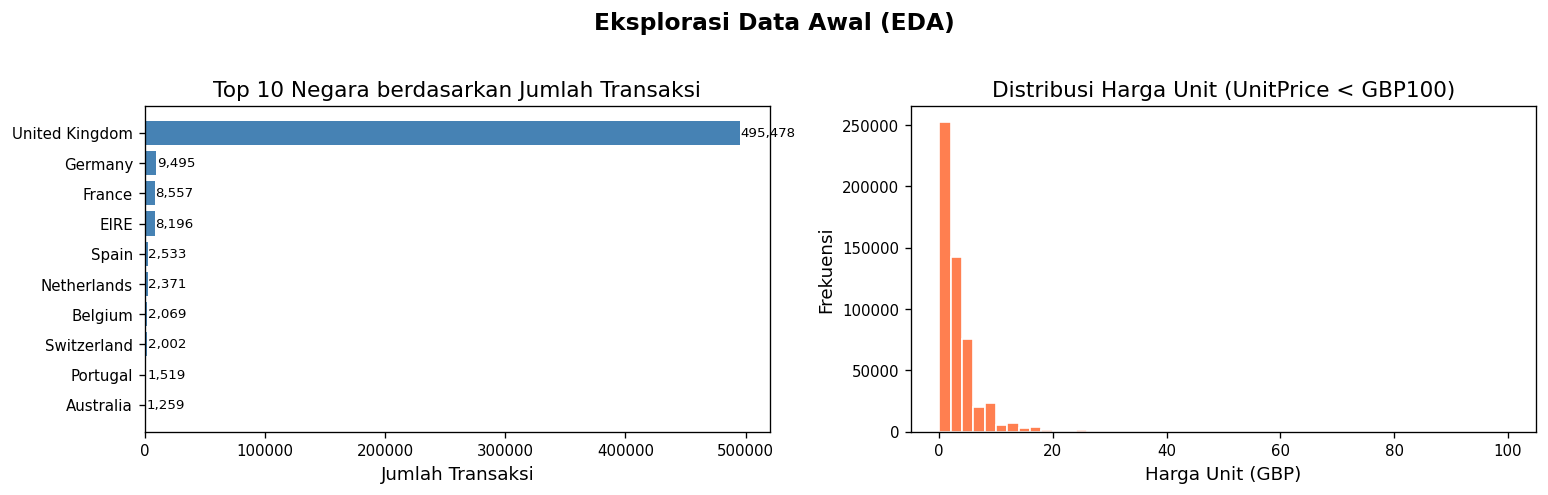

 EDA selesai.


In [7]:
# -----------------------------------------------------------
# Distribusi per negara (Top 10)
# -----------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Bar chart: transaksi per negara (top 10)
top_countries = df_raw['Country'].value_counts().head(10)
axes[0].barh(top_countries.index[::-1], top_countries.values[::-1], color='steelblue')
axes[0].set_title('Top 10 Negara berdasarkan Jumlah Transaksi')
axes[0].set_xlabel('Jumlah Transaksi')
for i, v in enumerate(top_countries.values[::-1]):
  axes[0].text(v + 500, i, f'{v:,}', va='center', fontsize=8)

# Histogram: distribusi UnitPrice (filter outlier > 0 & < 100)
price_filtered = df_raw[(df_raw['UnitPrice'] > 0) & (df_raw['UnitPrice'] < 100)]['UnitPrice']
axes[1].hist(price_filtered, bins=50, color='coral', edgecolor='white')
axes[1].set_title('Distribusi Harga Unit (UnitPrice < GBP100)')
axes[1].set_xlabel('Harga Unit (GBP)')
axes[1].set_ylabel('Frekuensi')

plt.suptitle('Eksplorasi Data Awal (EDA)', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()
print(' EDA selesai.')

---
## Bagian 3 - Feature Engineering (Ekstraksi 11 Fitur RFM-like)

###  Mengapa - Feature Engineering Diperlukan?
Dataset asli hanya memiliki 8 kolom bertipe transaksi (per baris = per item yang dibeli). Agar bisa melakukan segmentasi **per pelanggan**, kita perlu mentransformasi data level-transaksi menjadi data level-pelanggan dengan mengekstraksi fitur-fitur bermakna.

Paper referensi menggunakan **kerangka RFM yang diperluas** untuk menghasilkan 11 variabel fitur (Var1Var11) sebagaimana dijelaskan dalam **Table 1** paper:

| Variabel | Keterangan |
|----------|------------|
| **Var1** | Jumlah hari sejak pembelian terakhir (Recency) |
| **Var2** | Total jumlah transaksi/invoice unik (Frequency) |
| **Var3** | Total jumlah produk yang dibeli |
| **Var4** | Total pengeluaran keseluruhan (Monetary) |
| **Var5** | Rata-rata biaya per transaksi |
| **Var6** | Jumlah jenis/tipe produk berbeda yang pernah dibeli |
| **Var7** | Rata-rata jarak antar pembelian (dalam hari) |
| **Var8** | Estimasi hari pembelian berikutnya |
| **Var9** | Asal dari UK atau bukan (binary: 1 = UK, 0 = non-UK) |
| **Var10**| Frekuensi pembatalan transaksi |
| **Var11**| Rata-rata pengeluaran per bulan |

###  Langkah Pembersihan Data Sebelum - Feature Engineering
Sebelum menghitung fitur, perlu dilakukan **data cleaning** terlebih dahulu:
1. Hapus baris dengan `CustomerID` kosong (tidak bisa diidentifikasi pelanggannya)
2. Pisahkan transaksi **cancellation** (InvoiceNo berawalan `'C'`) dari transaksi normal
3. Filter `Quantity > 0` dan `UnitPrice > 0` untuk transaksi yang valid

In [8]:
# ============================================================
#  Bagian 3 - Feature Engineering
# ============================================================

# -----------------------------------------------------------
# 3.0  Data Cleaning Awal
# -----------------------------------------------------------
df = df_raw.copy()

# Konversi InvoiceDate ke datetime
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'], errors='coerce')

# Hapus baris tanpa CustomerID
n_before = len(df)
df.dropna(subset=['CustomerID'], inplace=True)
print(f'[Cleaning] Hapus missing CustomerID : {n_before - len(df):,} baris dihapus')

# Tandai transaksi cancellation (InvoiceNo diawali huruf 'C')
df['is_cancelled'] = df['InvoiceNo'].astype(str).str.startswith('C').astype(int)

# Pisahkan: data normal vs data cancelled
df_cancelled = df[df['is_cancelled'] == 1].copy()
df_valid  = df[(df['is_cancelled'] == 0) &
  (df['Quantity']  >  0) &
  (df['UnitPrice']  >  0)].copy()

# Hitung TotalPrice per baris transaksi
df_valid['TotalPrice'] = df_valid['Quantity'] * df_valid['UnitPrice']

# CustomerID ke integer
df_valid['CustomerID']  = df_valid['CustomerID'].astype(int)
df_cancelled['CustomerID'] = df_cancelled['CustomerID'].astype(int)

print(f'[Cleaning] Transaksi valid  : {len(df_valid):,} baris')
print(f'[Cleaning] Transaksi cancelled: {len(df_cancelled):,} baris')
print(f'[Cleaning] Pelanggan unik  : {df_valid["CustomerID"].nunique():,} pelanggan')

[Cleaning] Hapus missing CustomerID : 135,080 baris dihapus
[Cleaning] Transaksi valid  : 397,884 baris
[Cleaning] Transaksi cancelled: 8,905 baris
[Cleaning] Pelanggan unik  : 4,338 pelanggan


In [9]:
# -----------------------------------------------------------
# 3.1  Tentukan Tanggal Referensi (Snapshot Date)
#  hari setelah transaksi terakhir dalam dataset
# -----------------------------------------------------------
snapshot_date = df_valid['InvoiceDate'].max() + pd.Timedelta(days=1)
print(f' Snapshot date (tanggal referensi Recency): {snapshot_date.date()}')

 Snapshot date (tanggal referensi Recency): 2011-12-10


In [10]:
# -----------------------------------------------------------
# 3.2  Hitung 11 Fitur per Pelanggan
# -----------------------------------------------------------

#  Var1 : Recency  jumlah hari sejak pembelian terakhir
last_purchase = (df_valid.groupby('CustomerID')['InvoiceDate']
  .max()
  .reset_index()
  .rename(columns={'InvoiceDate': 'LastPurchase'}))
last_purchase['Var1'] = (snapshot_date - last_purchase['LastPurchase']).dt.days

#  Var2 : Frequency  jumlah invoice unik
var2 = (df_valid.groupby('CustomerID')['InvoiceNo']
  .nunique()
  .reset_index()
  .rename(columns={'InvoiceNo': 'Var2'}))

#  Var3 : Total jumlah produk yang dibeli
var3 = (df_valid.groupby('CustomerID')['Quantity']
  .sum()
  .reset_index()
  .rename(columns={'Quantity': 'Var3'}))

#  Var4 : Total pengeluaran (Monetary)
var4 = (df_valid.groupby('CustomerID')['TotalPrice']
  .sum()
  .reset_index()
  .rename(columns={'TotalPrice': 'Var4'}))

#  Var5 : Rata-rata biaya per transaksi
invoice_total = (df_valid.groupby(['CustomerID', 'InvoiceNo'])['TotalPrice']
  .sum()
  .reset_index())
var5 = (invoice_total.groupby('CustomerID')['TotalPrice']
  .mean()
  .reset_index()
  .rename(columns={'TotalPrice': 'Var5'}))

#  Var6 : Jumlah jenis/tipe produk berbeda
var6 = (df_valid.groupby('CustomerID')['StockCode']
  .nunique()
  .reset_index()
  .rename(columns={'StockCode': 'Var6'}))

#  Var7 : Rata-rata jarak antar pembelian (hari)
invoice_dates = (df_valid.groupby(['CustomerID', 'InvoiceNo'])['InvoiceDate']
  .min()
  .reset_index()
  .sort_values(['CustomerID', 'InvoiceDate']))
invoice_dates['days_diff'] = (invoice_dates.groupby('CustomerID')['InvoiceDate']
  .diff()
  .dt.days)
var7 = (invoice_dates.groupby('CustomerID')['days_diff']
  .mean()
  .reset_index()
  .rename(columns={'days_diff': 'Var7'}))
var7['Var7'] = var7['Var7'].fillna(0)

#  Var8 : Estimasi hari pembelian berikutnya
#  (Recency + rata-rata interval antar pembelian)
var8 = last_purchase[['CustomerID', 'Var1']].merge(var7, on='CustomerID')
var8['Var8'] = var8['Var1'] + var8['Var7']
var8 = var8[['CustomerID', 'Var8']]

#  Var9 : Asal UK (binary)
customer_country = (df_valid.groupby('CustomerID')['Country']
  .agg(lambda x: x.mode()[0])
  .reset_index())
customer_country['Var9'] = (customer_country['Country'] == 'United Kingdom').astype(int)
var9 = customer_country[['CustomerID', 'Var9']]

#  Var10 : Frekuensi pembatalan transaksi
var10_raw = (df_cancelled.groupby('CustomerID')['InvoiceNo']
  .count()
  .reset_index()
  .rename(columns={'InvoiceNo': 'Var10'}))

#  Var11 : Rata-rata pengeluaran per bulan
df_valid['YearMonth'] = df_valid['InvoiceDate'].dt.to_period('M')
monthly_spend = (df_valid.groupby(['CustomerID', 'YearMonth'])['TotalPrice']
  .sum()
  .reset_index())
var11 = (monthly_spend.groupby('CustomerID')['TotalPrice']
  .mean()
  .reset_index()
  .rename(columns={'TotalPrice': 'Var11'}))

print(' Semua 11 variabel berhasil dihitung.')

 Semua 11 variabel berhasil dihitung.


In [11]:
# -----------------------------------------------------------
# 3.3  Gabungkan semua fitur menjadi 1 DataFrame pelanggan
# -----------------------------------------------------------
feature_list = [
  last_purchase[['CustomerID', 'Var1']],
  var2, var3, var4, var5, var6, var7, var8, var9, var10_raw, var11
]

df_cust = feature_list[0]
for feat_df in feature_list[1:]:
  df_cust = df_cust.merge(feat_df, on='CustomerID', how='left')

# Var10 bisa 0 untuk pelanggan yang tidak pernah cancel
df_cust['Var10'] = df_cust['Var10'].fillna(0)

# Hapus pelanggan dengan nilai NaN pada fitur lain
n_before = len(df_cust)
df_cust.dropna(inplace=True)
print(f'[Cleaning] Hapus NaN sisa : {n_before - len(df_cust)} pelanggan')
print(f'\n Dataset pelanggan final : {df_cust.shape[0]:,} pelanggan  {df_cust.shape[1]} kolom')
print()
df_cust.head()

[Cleaning] Hapus NaN sisa : 0 pelanggan

 Dataset pelanggan final : 4,338 pelanggan  12 kolom



,CustomerID,Var1,Var2,Var3,Var4,Var5,Var6,Var7,Var8,Var9,Var10,Var11
0,12346,326,1,74215,77183.6000,77183.6000,1,0.0000,326.0000,1,1.0000,77183.6000
1,12347,2,7,2458,4310.0000,615.7143,103,60.3333,62.3333,0,0.0000,615.7143
2,12348,75,4,2341,1797.2400,449.3100,22,94.0000,169.0000,0,0.0000,449.3100
3,12349,19,1,631,1757.5500,1757.5500,73,0.0000,19.0000,0,0.0000,1757.5500
4,12350,310,1,197,334.4000,334.4000,17,0.0000,310.0000,0,0.0000,334.4000


In [12]:
# -----------------------------------------------------------
# 3.4  Deskripsi statistik 11 fitur yang telah diekstraksi
# -----------------------------------------------------------
feature_cols = [f'Var{i}' for i in range(1, 12)]

print(' Statistik deskriptif 11 fitur:')
df_cust[feature_cols].describe().T.style.background_gradient(cmap='Blues', axis=1)

 Statistik deskriptif 11 fitur:


,count,mean,std,min,25%,50%,75%,max
Var1,4338.000000,92.536422,100.014169,1.000000,18.000000,51.000000,142.000000,374.000000
Var2,4338.000000,4.272015,7.697998,1.000000,1.000000,2.000000,5.000000,209.000000
Var3,4338.000000,1191.289073,5046.081546,1.000000,160.000000,379.000000,992.750000,196915.000000
Var4,4338.000000,2054.266460,8989.230441,3.750000,307.415000,674.485000,1661.740000,280206.020000
Var5,4338.000000,419.166289,1796.537944,3.450000,178.625000,293.900000,430.113750,84236.250000
Var6,4338.000000,61.501153,85.366768,1.000000,16.000000,35.000000,77.000000,1787.000000
Var7,4338.000000,47.341149,63.183010,0.000000,0.000000,28.000000,68.000000,365.000000
Var8,4338.000000,139.877571,103.307980,1.000000,54.000000,109.416667,213.000000,374.000000
Var9,4338.000000,0.903642,0.295115,0.000000,1.000000,1.000000,1.000000,1.000000
Var10,4338.000000,2.032503,7.362394,0.000000,0.000000,0.000000,1.000000,226.000000


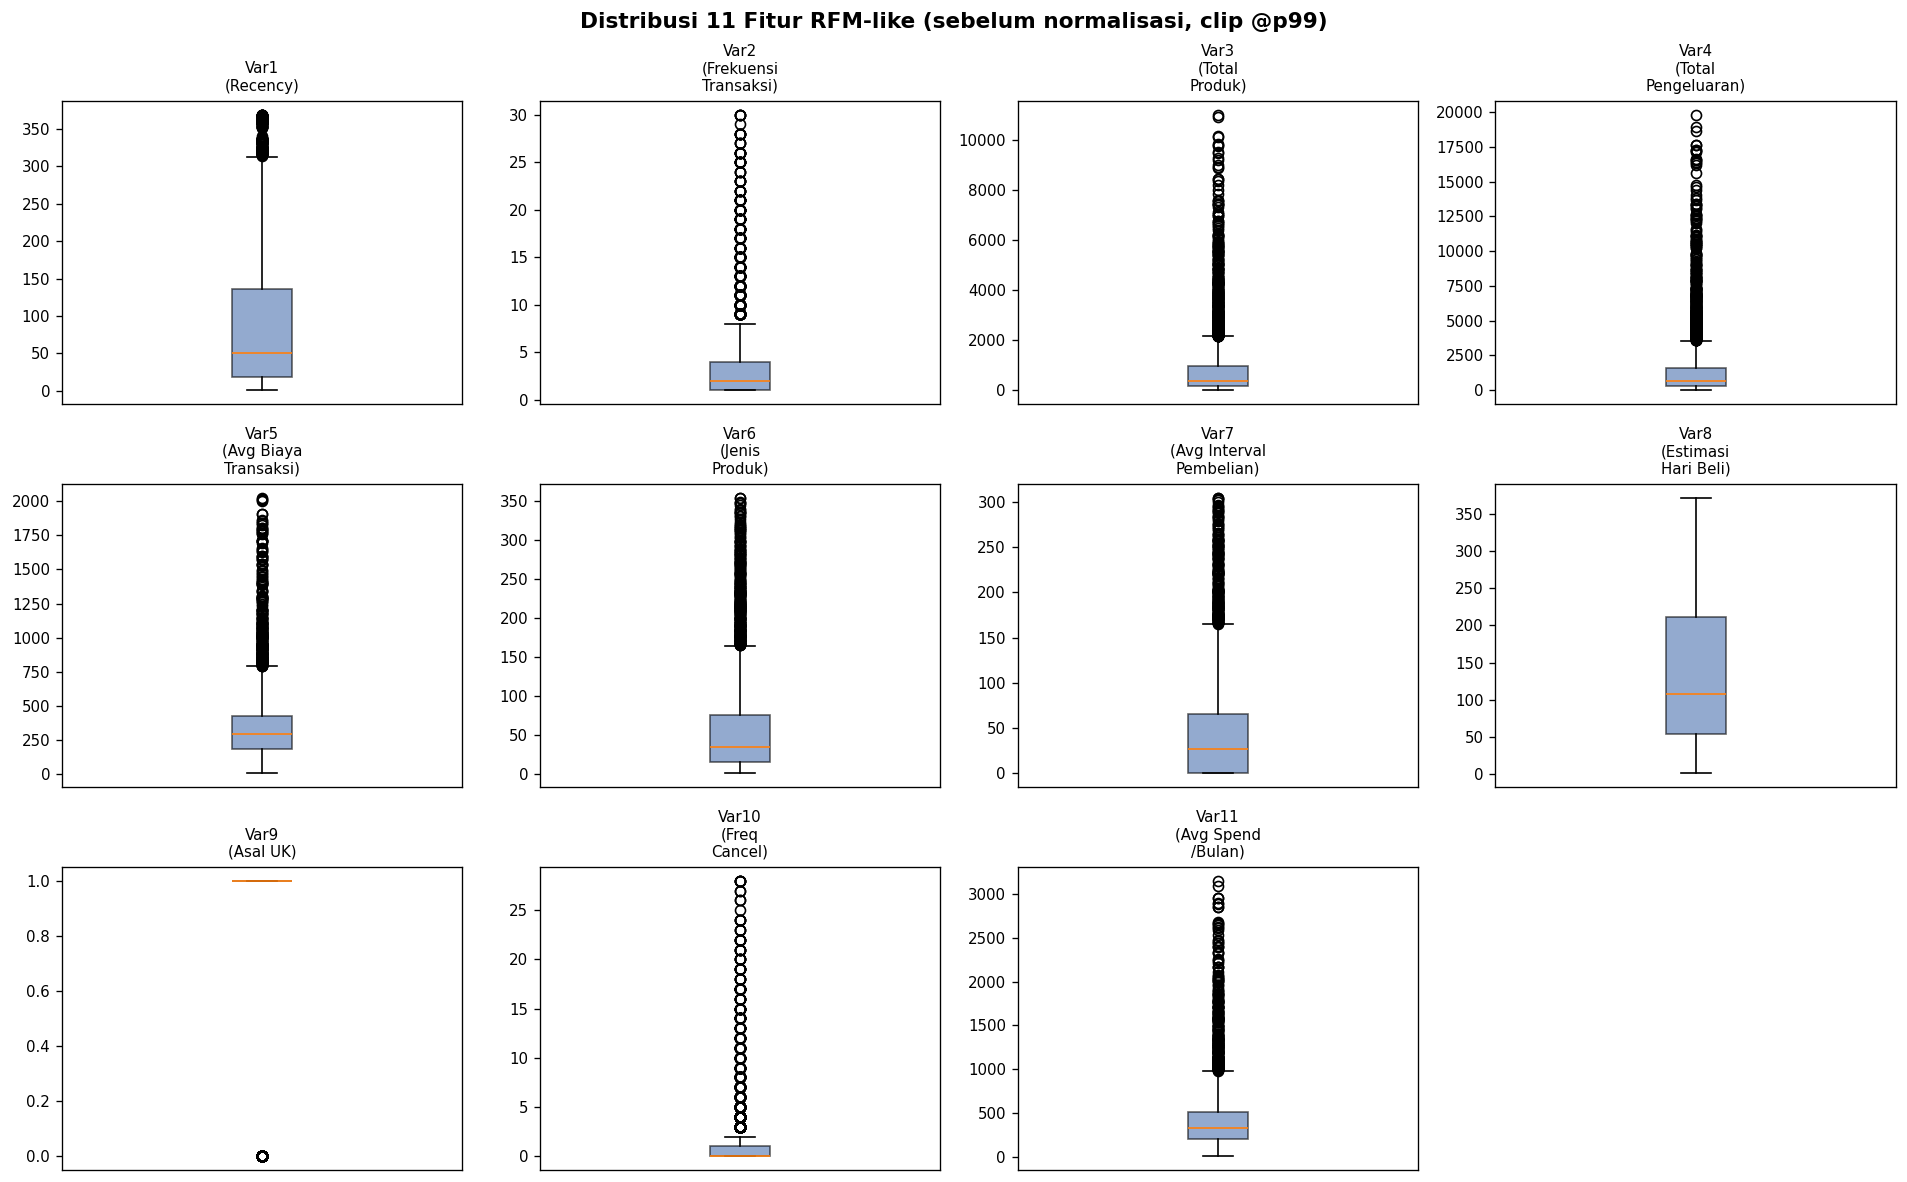

 Visualisasi distribusi fitur selesai.


In [13]:
# -----------------------------------------------------------
# 3.5  Visualisasi distribusi setiap fitur (boxplot)
# -----------------------------------------------------------
var_labels = [
  'Var1\n(Recency)',
  'Var2\n(Frekuensi\nTransaksi)',
  'Var3\n(Total\nProduk)',
  'Var4\n(Total\nPengeluaran)',
  'Var5\n(Avg Biaya\nTransaksi)',
  'Var6\n(Jenis\nProduk)',
  'Var7\n(Avg Interval\nPembelian)',
  'Var8\n(Estimasi\nHari Beli)',
  'Var9\n(Asal UK)',
  'Var10\n(Freq\nCancel)',
  'Var11\n(Avg Spend\n/Bulan)',
]

fig, axes = plt.subplots(3, 4, figsize=(16, 10))
axes_flat = axes.flatten()

for idx, (col, label) in enumerate(zip(feature_cols, var_labels)):
  ax = axes_flat[idx]
  data = df_cust[col]
  # Clip pada persentil 99 supaya outlier tidak merusak skala
  cap = data.quantile(0.99)
  ax.boxplot(data[data <= cap], vert=True, patch_artist=True,
  boxprops=dict(facecolor='#4C72B0', alpha=0.6))
  ax.set_title(label, fontsize=9)
  ax.set_xticks([])

# Matikan sumbu ekstra
for ax in axes_flat[len(feature_cols):]:
  ax.axis('off')

plt.suptitle('Distribusi 11 Fitur RFM-like (sebelum normalisasi, clip @p99)',
  fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()
print(' Visualisasi distribusi fitur selesai.')

---
## Bagian 4 - Preprocessing: Z-Score Normalization & Analisis Korelasi

###  4A. Z-Score Normalization
Fitur-fitur yang telah diekstraksi memiliki **skala yang sangat berbeda-beda**  misalnya Var4 (total pengeluaran) bisa bernilai jutaan, sedangkan Var9 (asal UK) hanya bernilai 0 atau 1. Perbedaan skala ini dapat mendominasi perhitungan jarak (Euclidean distance) yang digunakan oleh - K-Means.

Paper menggunakan **Z-score normalization** (standardisasi) dengan formula:

$$X_{norm} = \frac{X_o - \mu}{\sigma}$$

di mana $\mu$ adalah rata-rata dan $\sigma$ adalah standar deviasi dari setiap fitur. Hasil normalisasi menghasilkan distribusi dengan **mean = 0** dan **std = 1**.

###  4B. Analisis Korelasi
Setelah normalisasi, analisis korelasi dilakukan untuk mengidentifikasi **fitur-fitur yang redundan atau berkorelasi tinggi** antar satu sama lain. Korelasi tinggi antar fitur bisa menyebabkan multikolinearitas yang menurunkan kualitas clustering. Hasil analisis ini juga menjadi justifikasi untuk melakukan **PCA** di bagian berikutnya.

In [14]:
# ============================================================
#  Bagian 4A - Outlier Handling + Z-Score Normalization
# ============================================================

# Catatan penting:
# Dataset Online Retail punya outlier sangat ekstrem, misalnya customer dengan
# total pembelian atau pengeluaran jauh lebih besar dari mayoritas pelanggan.
# Jika outlier langsung masuk K-Means, satu centroid bisa "habis" hanya untuk
# menangkap outlier sehingga muncul cluster sangat kecil (0.3% / 0.4%).
#
# Karena itu, sebelum StandardScaler kita lakukan winsorization/clipping p1-p99
# untuk fitur numerik non-binary. Var9 tidak di-clip karena merupakan flag UK.

feature_cols = [f'Var{i}' for i in range(1, 12)]
binary_cols = ['Var9']
clip_cols = [c for c in feature_cols if c not in binary_cols]

df_cust_original = df_cust.copy()
df_cust_model = df_cust.copy()

clip_report = []
for col in clip_cols:
    lower = df_cust_model[col].quantile(0.01)
    upper = df_cust_model[col].quantile(0.99)
    before_min = df_cust_model[col].min()
    before_max = df_cust_model[col].max()
    df_cust_model[col] = df_cust_model[col].clip(lower=lower, upper=upper)
    clip_report.append({
        'Fitur': col,
        'Lower p1': lower,
        'Upper p99': upper,
        'Min sebelum': before_min,
        'Max sebelum': before_max,
        'Max sesudah': df_cust_model[col].max()
    })

# Mulai bagian ini, model clustering memakai fitur yang sudah di-clip.
# CustomerID dan struktur data tetap sama.
df_cust = df_cust_model.copy()

X_raw = df_cust[feature_cols].values

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_raw)

df_scaled = pd.DataFrame(X_scaled, columns=feature_cols)

print('Outlier handling + Z-Score Normalization selesai.')
print(f'  Fitur numerik di-clip pada p1-p99 : {len(clip_cols)} fitur')
print(f'  Fitur binary tidak di-clip        : {binary_cols}')
print(f'  Shape data setelah normalisasi   : {X_scaled.shape}')
print('  Mean per fitur (should ~0):')
print('  ', np.round(df_scaled.mean().values, 4))
print('  Std  per fitur (should ~1):')
print('  ', np.round(df_scaled.std().values, 4))

print('\nRingkasan clipping outlier:')
display(pd.DataFrame(clip_report).round(2))


Outlier handling + Z-Score Normalization selesai.
  Fitur numerik di-clip pada p1-p99 : 10 fitur
  Fitur binary tidak di-clip        : ['Var9']
  Shape data setelah normalisasi   : (4338, 11)
  Mean per fitur (should ~0):
   [-0. -0.  0.  0. -0. -0. -0. -0.  0.  0.  0.]
  Std  per fitur (should ~1):
   [1.0001 1.0001 1.0001 1.0001 1.0001 1.0001 1.0001 1.0001 1.0001 1.0001
 1.0001]

Ringkasan clipping outlier:


,Fitur,Lower p1,Upper p99,Min sebelum,Max sebelum,Max sesudah
0,Var1,1.0000,369.0000,1.0000,374.0000,369.0000
1,Var2,1.0000,30.0000,1.0000,209.0000,30.0000
2,Var3,12.0000,11046.5800,1.0000,196915.0000,11046.5800
3,Var4,52.2000,19881.0000,3.7500,280206.0200,19881.0000
4,Var5,43.3100,2031.1600,3.4500,84236.2500,2031.1600
5,Var6,1.0000,354.0000,1.0000,1787.0000,354.0000
6,Var7,0.0000,305.6300,0.0000,365.0000,305.6300
7,Var8,7.0600,372.0000,1.0000,374.0000,372.0000
8,Var10,0.0000,28.6300,0.0000,226.0000,28.6300
9,Var11,47.0100,3176.8100,3.7500,84236.2500,3176.8100


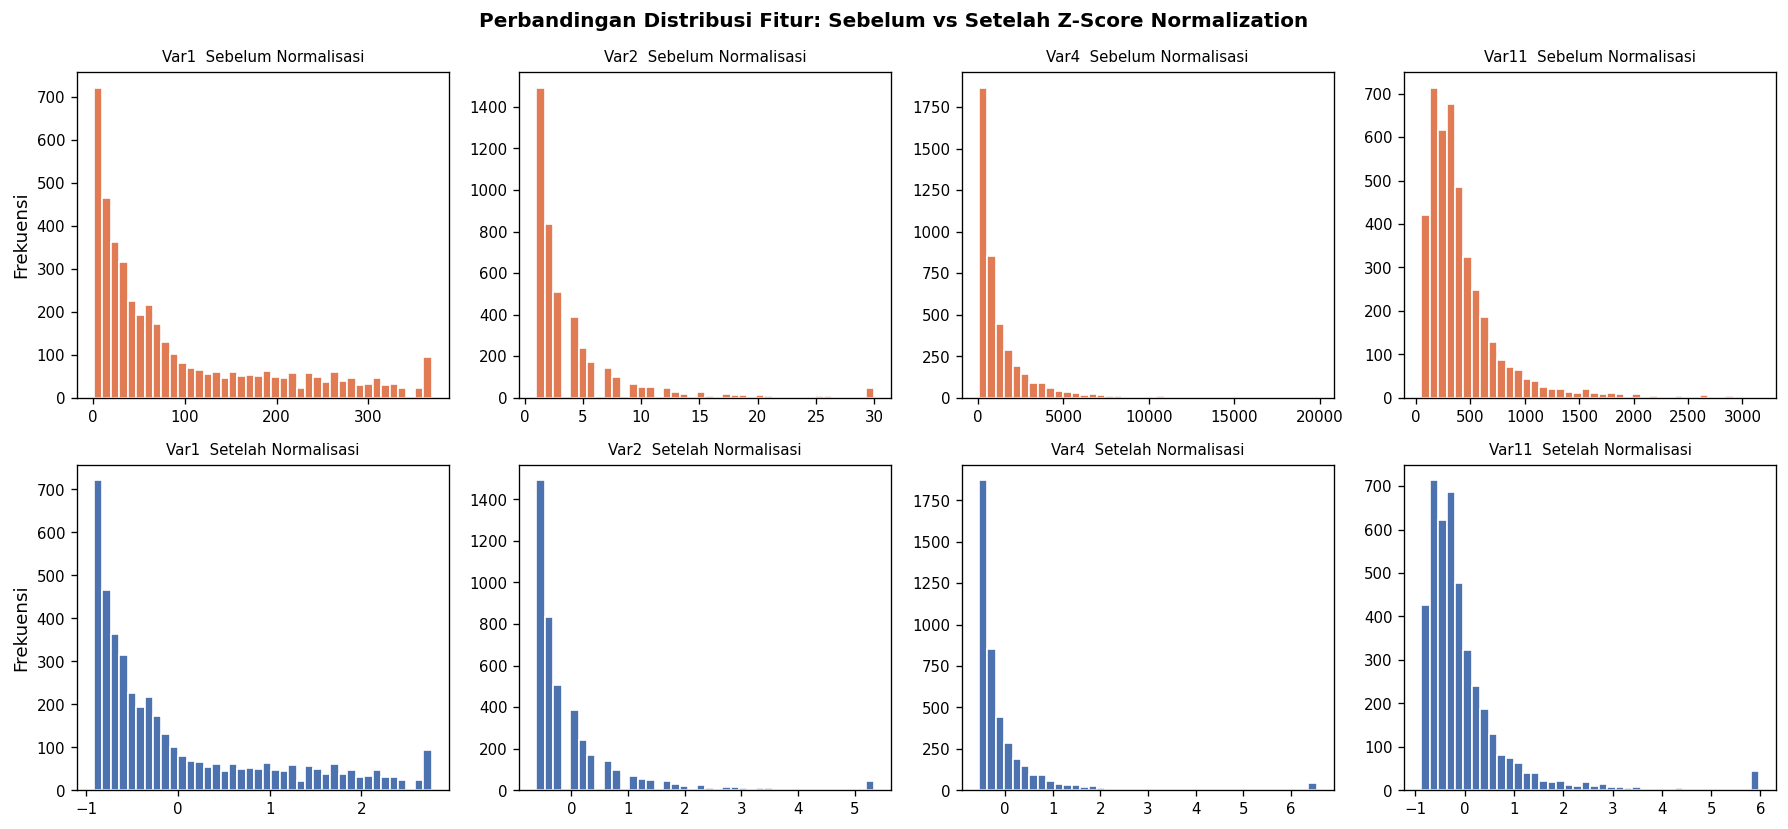

In [15]:
# -----------------------------------------------------------
# Visualisasi perbandingan distribusi sebelum vs sesudah normalisasi
# -----------------------------------------------------------
fig, axes = plt.subplots(2, 4, figsize=(15, 7))

sample_vars = ['Var1', 'Var2', 'Var4', 'Var11']  # pilih 4 fitur representatif

for col_idx, var in enumerate(sample_vars):
  cap = df_cust[var].quantile(0.99)
  data_before = df_cust[var][df_cust[var] <= cap]
  data_after  = df_scaled[var]

  # Sebelum normalisasi
  axes[0, col_idx].hist(data_before, bins=40, color='#e07b54', edgecolor='white')
  axes[0, col_idx].set_title(f'{var}  Sebelum Normalisasi', fontsize=9)
  axes[0, col_idx].set_ylabel('Frekuensi' if col_idx == 0 else '')

  # Sesudah normalisasi
  axes[1, col_idx].hist(data_after, bins=40, color='#4C72B0', edgecolor='white')
  axes[1, col_idx].set_title(f'{var}  Setelah Normalisasi', fontsize=9)
  axes[1, col_idx].set_ylabel('Frekuensi' if col_idx == 0 else '')

plt.suptitle('Perbandingan Distribusi Fitur: Sebelum vs Setelah Z-Score Normalization',
  fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

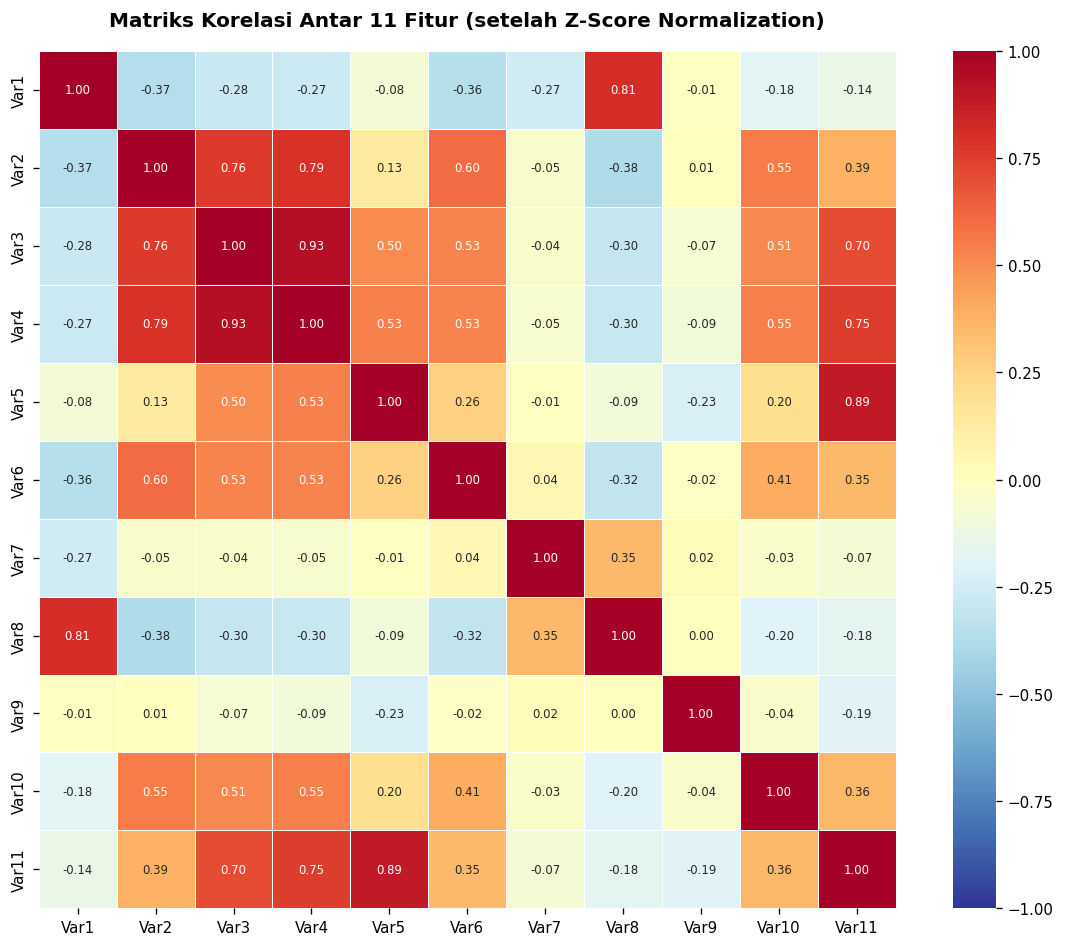

 Pasangan fitur dengan korelasi tinggi (|r| >= 0.80):
Fitur A Fitur B  Korelasi (r)
   Var1    Var8        0.8073
   Var3    Var4        0.9330
   Var5   Var11        0.8861

  Terdapat 3 pasangan fitur berkorelasi tinggi.
  Ini menjadi justifikasi dilakukannya - PCA untuk reduksi dimensi.


In [16]:
# ============================================================
#  Bagian 4B - Analisis Korelasi Antar Fitur
# ============================================================

corr_matrix = df_scaled.corr()

fig, ax = plt.subplots(figsize=(10, 8))

mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)  # sembunyikan sisi atas duplikat
sns.heatmap(
  corr_matrix,
  ax=ax,
  annot=True,
  fmt='.2f',
  cmap='RdYlBu_r',  # merah = korelasi positif, biru = korelasi negatif
  vmin=-1, vmax=1,
  linewidths=0.4,
  square=True,
  annot_kws={'size': 7},
)

ax.set_title('Matriks Korelasi Antar 11 Fitur (setelah Z-Score Normalization)',
  fontsize=12, fontweight='bold', pad=15)
plt.tight_layout()
plt.show()

# -----------------------------------------------------------
# Identifikasi pasangan fitur dengan korelasi sangat tinggi (|r| >= 0.80)
# -----------------------------------------------------------
print(' Pasangan fitur dengan korelasi tinggi (|r| >= 0.80):')
threshold = 0.80
high_corr_pairs = []
for i in range(len(feature_cols)):
  for j in range(i + 1, len(feature_cols)):
    r = corr_matrix.iloc[i, j]
    if abs(r) >= threshold:
      high_corr_pairs.append((feature_cols[i], feature_cols[j], round(r, 4)))

if high_corr_pairs:
  df_high_corr = pd.DataFrame(high_corr_pairs, columns=['Fitur A', 'Fitur B', 'Korelasi (r)'])
  print(df_high_corr.to_string(index=False))
  print(f'\n  Terdapat {len(high_corr_pairs)} pasangan fitur berkorelasi tinggi.')
  print('  Ini menjadi justifikasi dilakukannya - PCA untuk reduksi dimensi.')
else:
  print('  Tidak ada pasangan fitur dengan |r| >= 0.80.')

###  Interpretasi Analisis Korelasi

Dari heatmap di atas dapat diamati beberapa pola penting:

- **Var1 (Recency)** berkorelasi positif signifikan dengan beberapa variabel  sesuai dengan temuan paper yang menyatakan bahwa *"var1 exhibits a strong positive correlation with feature variables 2, 3, 5, and 9"*.
- **Var4 (Total Pengeluaran)** dan **Var11 (Avg Spend/Bulan)** berkorelasi sangat tinggi, karena keduanya sama-sama mengukur nilai moneter pelanggan.
- **Var2 (Frekuensi)** dan **Var6 (Jenis Produk)** berkorelasi positif  pelanggan yang sering bertransaksi cenderung membeli lebih banyak jenis produk.

Korelasi tinggi antar fitur mengindikasikan **redundansi informasi**, yang dapat menurunkan kualitas clustering. Oleh karena itu, paper menggunakan **PCA** untuk mengkompresi dimensi sekaligus menghilangkan noise multikolinearitas.

---
## Bagian 5 - PCA: Reduksi Dimensi

###  Apa itu - PCA?
**Principal Component Analysis (PCA)** adalah metode reduksi dimensi linier yang bekerja dengan cara:
1. Menghitung **matriks kovarian** dari data yang telah dinormalisasi
2. Melakukan **dekomposisi nilai eigen** untuk mendapatkan *eigenvector* dan *eigenvalue*
3. Mengurutkan komponen berdasarkan **variansi yang dijelaskan** (*explained variance*)
4. Memilih sejumlah **K komponen utama** pertama yang merepresentasikan sebagian besar informasi

###  Tujuan dalam Paper
Paper menyatakan:
> *"The first 6 principal components, which account for more than 90% of the explained variance, are selected as input."*

Sehingga dimensi data direduksi dari **11 dimensi  6 dimensi**, dengan tetap mempertahankan  90% informasi dari data asli. Hal ini:
- Mengurangi noise dan redundansi fitur
- Mempercepat proses clustering
- Meningkatkan kemampuan model mengidentifikasi pola tersembunyi

In [17]:
# ============================================================
#  Bagian 5 - PCA (Principal Component Analysis)
# ============================================================

# -----------------------------------------------------------
# 5.1  Fit PCA dengan semua 11 komponen (untuk analisis variance)
# -----------------------------------------------------------
pca_full = PCA(n_components=len(feature_cols), random_state=RANDOM_SEED)
pca_full.fit(X_scaled)

explained_var_ratio = pca_full.explained_variance_ratio_
cumulative_var_ratio = np.cumsum(explained_var_ratio)

print('Explained Variance per komponen PCA:')
print('-' * 52)
print(f'  {"PC":<6} {"Variance":>12} {"Kumulatif":>12}')
print('-' * 52)
for i, (ev, cv) in enumerate(zip(explained_var_ratio, cumulative_var_ratio), 1):
    marker = '  <-- 6 PC dipakai paper' if i == 6 else ''
    print(f'  PC{i:<4} {ev*100:>11.2f}% {cv*100:>11.2f}%{marker}')
print('-' * 52)
print(f'Kumulatif 6 PC pertama: {cumulative_var_ratio[5]*100:.2f}%')


Explained Variance per komponen PCA:
----------------------------------------------------
  PC         Variance    Kumulatif
----------------------------------------------------
  PC1          42.11%       42.11%
  PC2          15.95%       58.07%
  PC3          11.13%       69.20%
  PC4          10.56%       79.76%
  PC5           7.94%       87.69%
  PC6           5.15%       92.84%  <-- 6 PC dipakai paper
  PC7           4.77%       97.61%
  PC8           1.28%       98.89%
  PC9           0.65%       99.54%
  PC10          0.45%      100.00%
  PC11          0.00%      100.00%
----------------------------------------------------
Kumulatif 6 PC pertama: 92.84%


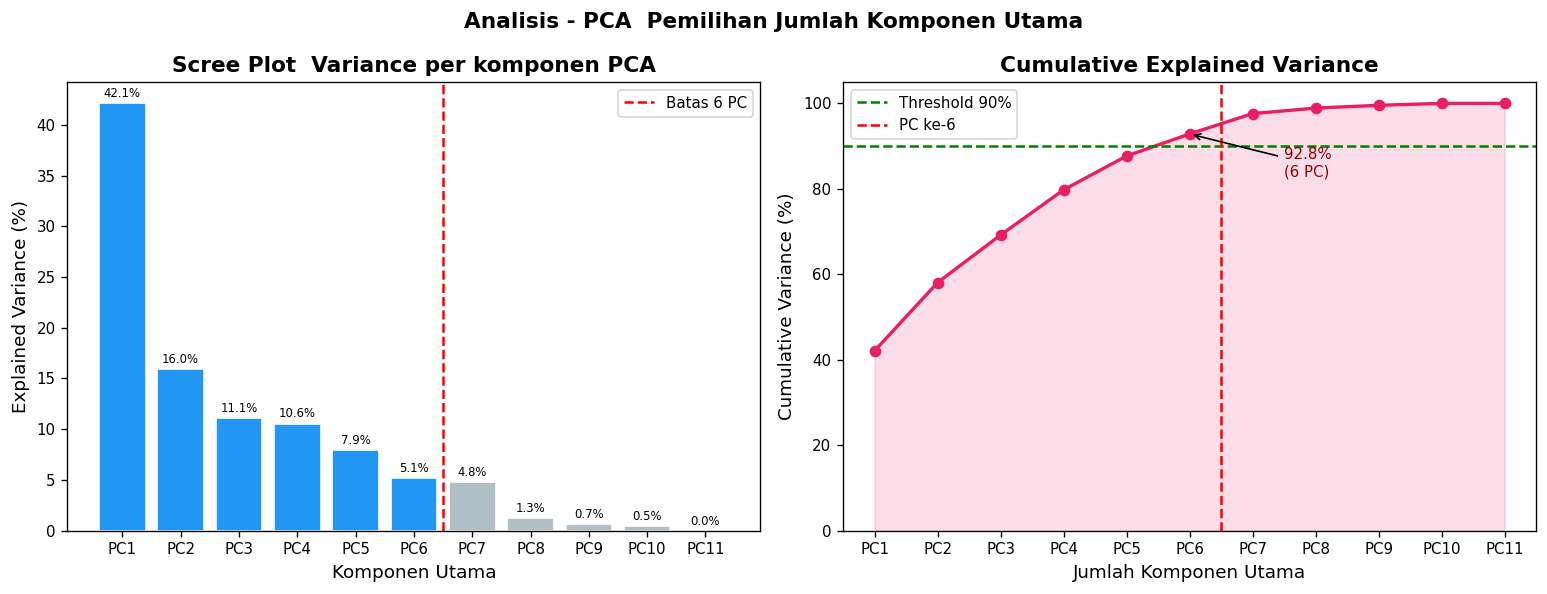

In [18]:
# -----------------------------------------------------------
# 5.2  Visualisasi Scree Plot & Cumulative Variance
#  (mereproduksi Fig. 8(A) dari paper)
# -----------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

n_components = len(feature_cols)
pc_labels  = [f'PC{i}' for i in range(1, n_components + 1)]

#  Plot kiri: Scree Plot
bar_colors = ['#2196F3' if i < 6 else '#B0BEC5' for i in range(n_components)]
bars = axes[0].bar(pc_labels, explained_var_ratio * 100, color=bar_colors, edgecolor='white')
axes[0].set_title('Scree Plot  Variance per komponen PCA', fontweight='bold')
axes[0].set_xlabel('Komponen Utama')
axes[0].set_ylabel('Explained Variance (%)')
axes[0].axvline(x=5.5, color='red', linestyle='--', linewidth=1.5, label='Batas 6 PC')
axes[0].legend(fontsize=9)
for bar, val in zip(bars, explained_var_ratio * 100):
  axes[0].text(bar.get_x() + bar.get_width() / 2,
  bar.get_height() + 0.3,
  f'{val:.1f}%', ha='center', va='bottom', fontsize=7)

#  Plot kanan: Cumulative Variance
axes[1].plot(pc_labels, cumulative_var_ratio * 100,
  marker='o', color='#E91E63', linewidth=2, markersize=6)
axes[1].axhline(y=90, color='green', linestyle='--', linewidth=1.5, label='Threshold 90%')
axes[1].axvline(x=5.5, color='red',  linestyle='--', linewidth=1.5, label='PC ke-6')
axes[1].fill_between(range(n_components), cumulative_var_ratio * 100,
  alpha=0.15, color='#E91E63')
axes[1].set_title('Cumulative Explained Variance', fontweight='bold')
axes[1].set_xlabel('Jumlah Komponen Utama')
axes[1].set_ylabel('Cumulative Variance (%)')
axes[1].set_ylim([0, 105])
axes[1].legend(fontsize=9)

# Anotasi titik 6 PC
axes[1].annotate(
  f'{cumulative_var_ratio[5]*100:.1f}%\n(6 PC)',
  xy=(5, cumulative_var_ratio[5] * 100),
  xytext=(6.5, cumulative_var_ratio[5] * 100 - 10),
  arrowprops=dict(arrowstyle='->', color='black'),
  fontsize=9, color='darkred'
)

plt.suptitle('Analisis - PCA  Pemilihan Jumlah Komponen Utama', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

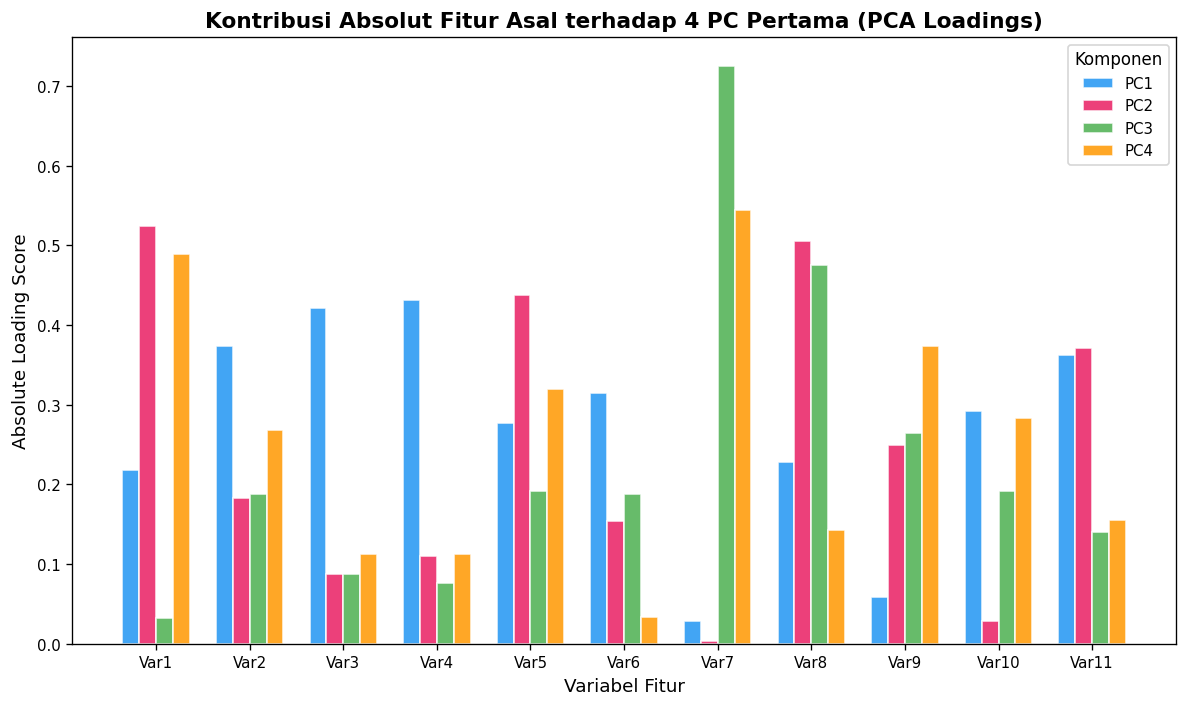

In [19]:
# -----------------------------------------------------------
# 5.3  Visualisasi Kontribusi Fitur Asal terhadap PCA
#  (mereproduksi ide Fig. 8(B) dari paper)
# -----------------------------------------------------------
N_TOP_PC = 4  # tampilkan 4 PC pertama

loadings = pd.DataFrame(
    np.abs(pca_full.components_[:N_TOP_PC].T),
    index=feature_cols,
    columns=[f'PC{i+1}' for i in range(N_TOP_PC)]
)

fig, ax = plt.subplots(figsize=(10, 6))
x_pos = np.arange(len(feature_cols))
width = 0.18
colors = ['#2196F3', '#E91E63', '#4CAF50', '#FF9800']

for i, (pc_col, color) in enumerate(zip(loadings.columns, colors)):
    ax.bar(
        x_pos + i * width,
        loadings[pc_col],
        width,
        label=pc_col,
        color=color,
        alpha=0.85,
        edgecolor='white'
    )

ax.set_xticks(x_pos + width * (N_TOP_PC - 1) / 2)
ax.set_xticklabels(feature_cols, rotation=0)
ax.set_title('Kontribusi Absolut Fitur Asal terhadap 4 PC Pertama (PCA Loadings)',
             fontweight='bold')
ax.set_xlabel('Variabel Fitur')
ax.set_ylabel('Absolute Loading Score')
ax.legend(title='Komponen', fontsize=9)
plt.tight_layout()
plt.show()


In [20]:
# -----------------------------------------------------------
# 5.4  Transformasi Data: 11 dimensi -> 6 komponen utama
# -----------------------------------------------------------
N_PCA_COMPONENTS = 6

pca_final = PCA(n_components=N_PCA_COMPONENTS, random_state=RANDOM_SEED)
X_pca = pca_final.fit_transform(X_scaled)

df_pca = pd.DataFrame(X_pca, columns=[f'PC{i+1}' for i in range(N_PCA_COMPONENTS)])

print('Transformasi PCA selesai.')
print(f'  Dimensi sebelum PCA : {X_scaled.shape[1]} fitur')
print(f'  Dimensi setelah PCA : {X_pca.shape[1]} komponen utama')
print(f'  Informasi yang dipertahankan: {pca_final.explained_variance_ratio_.sum()*100:.2f}%')
print()
print('Preview 5 baris data setelah PCA:')
df_pca.head()


Transformasi PCA selesai.
  Dimensi sebelum PCA : 11 fitur
  Dimensi setelah PCA : 6 komponen utama
  Informasi yang dipertahankan: 92.84%

Preview 5 baris data setelah PCA:


,PC1,PC2,PC3,PC4,PC5,PC6
0,7.6644,8.1390,-0.6413,-0.5229,3.7165,0.0912
1,2.0398,0.3824,-0.9224,1.8309,-2.1247,-0.8074
2,0.3178,1.1121,-0.2795,1.7127,-2.2764,-0.1157
3,2.5572,2.8805,-3.3602,3.4052,-0.2124,-0.0100
4,-1.7042,2.7352,-0.8417,-0.2389,-2.7084,-0.5259


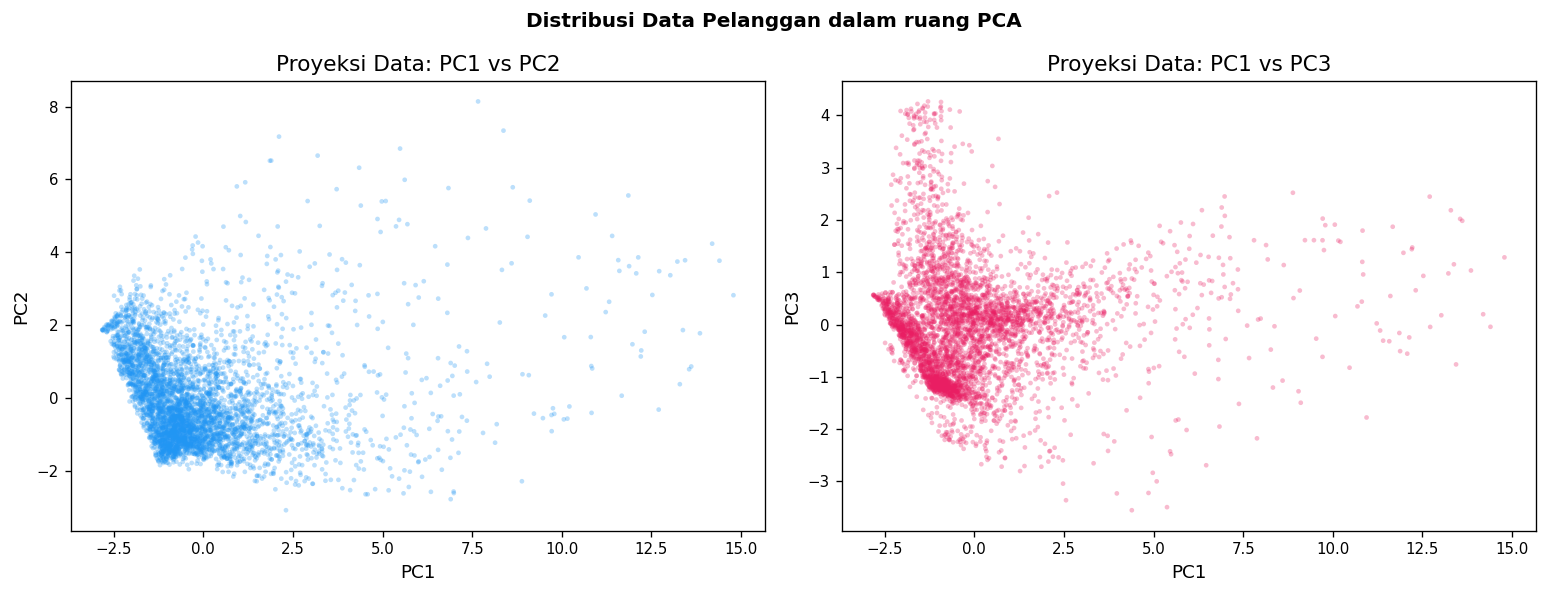

In [21]:
# -----------------------------------------------------------
# 5.5  Scatter Plot: Visualisasi data pada 2 PC pertama
# -----------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# PC1 vs PC2
axes[0].scatter(X_pca[:, 0], X_pca[:, 1],
  alpha=0.3, s=8, c='#2196F3', edgecolors='none')
axes[0].set_xlabel('PC1')
axes[0].set_ylabel('PC2')
axes[0].set_title('Proyeksi Data: PC1 vs PC2')

# PC1 vs PC3
axes[1].scatter(X_pca[:, 0], X_pca[:, 2],
  alpha=0.3, s=8, c='#E91E63', edgecolors='none')
axes[1].set_xlabel('PC1')
axes[1].set_ylabel('PC3')
axes[1].set_title('Proyeksi Data: PC1 vs PC3')

plt.suptitle('Distribusi Data Pelanggan dalam ruang PCA',
  fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

---
## Bagian 6 - K-means-QLDE Clustering

### Tujuan Bagian Ini
Bagian ini menyesuaikan metode utama paper dengan menggabungkan:

1. **Elbow Method** untuk memilih jumlah kluster optimal, yaitu K=6.
2. **Differential Evolution (DE)** untuk mencari kandidat centroid.
3. **Q-learning** untuk adaptasi nilai scaling factor `F` pada proses DE.
4. **K-Means** dengan centroid awal hasil QLDE.
5. **SSE/Inertia** sebagai objective function yang diminimalkan.

Secara sederhana:

```text
Data PCA
-> Elbow Method memilih K=6
-> QLDE mencari centroid awal terbaik dengan objective SSE
-> K-Means final memakai centroid dari QLDE
-> Output cluster pelanggan C1-C6
```

> Catatan implementasi: paper menggunakan MATLAB dan detail eksperimen yang tidak seluruh hyperparameter-nya ditampilkan secara lengkap. Kode ini adalah implementasi Python yang mengikuti struktur metode paper: PCA + Q-learning + Differential Evolution + K-Means dengan objective SSE.


In [22]:
# ============================================================
#  Bagian 6 - K-means-QLDE Clustering
# ============================================================

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score

print('Library clustering berhasil diimpor.')


Library clustering berhasil diimpor.


### 6.1 Elbow Method  Menentukan Jumlah Kluster Optimal (K)

**Elbow Method** bekerja dengan menghitung **Sum of Squared Errors (SSE)** atau *inertia* untuk setiap nilai K, yaitu total jarak kuadrat antara setiap titik data dengan pusat klusternya yang paling dekat. Secara matematis:

$$SSE = \sum_{l=1}^{K} \sum_{C(i)=l} \|x_i - m_l\|^2$$

Semakin besar K, SSE akan terus menurun. Kita mencari titik **"siku" (elbow)**  yaitu K di mana penurunan SSE mulai melambat secara signifikan  sebagai titik optimal.


In [23]:
# -----------------------------------------------------------
# 6.1  Elbow Method: Hitung SSE untuk K = 2 sampai 12
# -----------------------------------------------------------

K_RANGE  = range(2, 13)
sse_values  = []
sil_values  = []

print(' Menghitung SSE & Silhouette Score untuk K = 2..12 ...')
print('' * 50)

for k in K_RANGE:
  km = KMeans(n_clusters=k, init='k-means++', n_init=10,
  max_iter=300, random_state=RANDOM_SEED)
  km.fit(X_pca)
  sse = km.inertia_
  sil = silhouette_score(X_pca, km.labels_, sample_size=2000,
  random_state=RANDOM_SEED)
  sse_values.append(sse)
  sil_values.append(sil)
  print(f'  K={k:2d}  |  SSE = {sse:>10,.2f}  |  Silhouette = {sil:.4f}')

print('' * 50)
print(' Kalkulasi selesai.')


 Menghitung SSE & Silhouette Score untuk K = 2..12 ...

  K= 2  |  SSE =  32,135.61  |  Silhouette = 0.5169
  K= 3  |  SSE =  26,125.10  |  Silhouette = 0.2716
  K= 4  |  SSE =  22,620.47  |  Silhouette = 0.2978
  K= 5  |  SSE =  19,411.23  |  Silhouette = 0.3295
  K= 6  |  SSE =  16,457.97  |  Silhouette = 0.3355
  K= 7  |  SSE =  14,276.50  |  Silhouette = 0.3468
  K= 8  |  SSE =  12,876.92  |  Silhouette = 0.3289
  K= 9  |  SSE =  11,949.30  |  Silhouette = 0.2918
  K=10  |  SSE =  11,291.96  |  Silhouette = 0.2920
  K=11  |  SSE =  10,715.51  |  Silhouette = 0.3041
  K=12  |  SSE =  10,148.44  |  Silhouette = 0.3084

 Kalkulasi selesai.


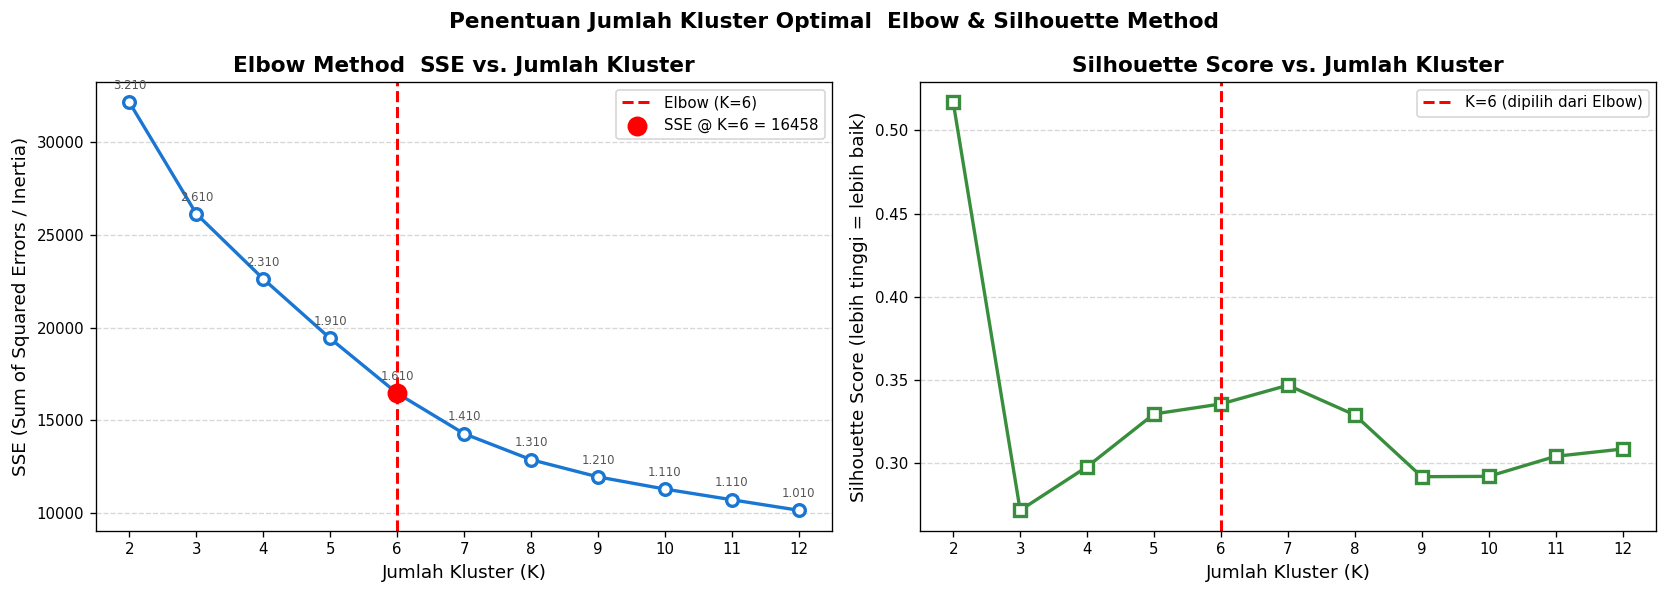


 Jumlah kluster optimal dipilih: K = 6
  (Konsisten dengan temuan paper: "at K=6, a clear inflection point")


In [24]:
# -----------------------------------------------------------
# 6.2  Visualisasi Elbow Curve (mereproduksi Fig. 9 paper)
# -----------------------------------------------------------

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
k_list = list(K_RANGE)

#  Plot kiri: SSE (Elbow Curve)
axes[0].plot(k_list, sse_values, marker='o', color='#1976D2',
  linewidth=2, markersize=7, markerfacecolor='white',
  markeredgewidth=2)
axes[0].axvline(x=6, color='red', linestyle='--', linewidth=1.8,
  label='Elbow (K=6)')
axes[0].scatter([6], [sse_values[k_list.index(6)]], color='red',
  s=120, zorder=5, label=f'SSE @ K=6 = {sse_values[k_list.index(6)]:.0f}')
axes[0].set_title('Elbow Method  SSE vs. Jumlah Kluster', fontweight='bold')
axes[0].set_xlabel('Jumlah Kluster (K)')
axes[0].set_ylabel('SSE (Sum of Squared Errors / Inertia)')
axes[0].set_xticks(k_list)
axes[0].legend(fontsize=9)
axes[0].grid(axis='y', linestyle='--', alpha=0.5)

# Anotasi nilai SSE
for k, s in zip(k_list, sse_values):
  axes[0].annotate(f'{s/1e4:.1f}10',
  xy=(k, s), xytext=(0, 8), textcoords='offset points',
  ha='center', fontsize=7, color='#555')

#  Plot kanan: Silhouette Score
axes[1].plot(k_list, sil_values, marker='s', color='#388E3C',
  linewidth=2, markersize=7, markerfacecolor='white',
  markeredgewidth=2)
axes[1].axvline(x=6, color='red', linestyle='--', linewidth=1.8,
  label='K=6 (dipilih dari Elbow)')
axes[1].set_title('Silhouette Score vs. Jumlah Kluster', fontweight='bold')
axes[1].set_xlabel('Jumlah Kluster (K)')
axes[1].set_ylabel('Silhouette Score (lebih tinggi = lebih baik)')
axes[1].set_xticks(k_list)
axes[1].legend(fontsize=9)
axes[1].grid(axis='y', linestyle='--', alpha=0.5)

plt.suptitle('Penentuan Jumlah Kluster Optimal  Elbow & Silhouette Method',
  fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('elbow_silhouette.png', dpi=120, bbox_inches='tight')
plt.show()

K_OPTIMAL = 6
print(f'\n Jumlah kluster optimal dipilih: K = {K_OPTIMAL}')
print(f'  (Konsisten dengan temuan paper: "at K=6, a clear inflection point")')


### 6.3 Menjalankan K-means-QLDE Final dengan K=6

Setelah K=6 ditetapkan, tahap berikutnya adalah mengoptimasi centroid awal K-Means dengan **QLDE**.

Komponen yang dipakai:
- **Individual DE** = kandidat centroid K-Means dalam bentuk vektor.
- **Fitness/objective** = SSE/Inertia, semakin kecil semakin baik.
- **Mutation, crossover, selection** = mekanisme Differential Evolution.
- **Q-table** = memilih aksi perubahan scaling factor `F`.
- **Aksi Q-learning** = `lambda = [-0.01, 0, +0.01]`.
- **K-Means final** = dijalankan dengan `init=centroid_hasil_QLDE`.


In [25]:
# -----------------------------------------------------------
# 6.3  Implementasi QLDE untuk optimasi centroid K-Means
#      Versi diperbaiki: penalti cluster terlalu kecil
# -----------------------------------------------------------

MIN_CLUSTER_PCT = 0.05        # target minimal 5% per cluster agar tidak muncul cluster 0.3%
SIZE_PENALTY_WEIGHT = 5e7     # makin besar = makin keras menolak cluster terlalu kecil
EMPTY_CLUSTER_PENALTY = 1e12  # penalti cluster kosong
QLDE_RUN_SEEDS = [RANDOM_SEED, RANDOM_SEED + 11, RANDOM_SEED + 23]


def compute_sse_and_labels(X, centers):
    """Menghitung SSE/Inertia dan label berdasarkan centroid."""
    distances = np.sum((X[:, None, :] - centers[None, :, :]) ** 2, axis=2)
    labels = np.argmin(distances, axis=1)
    min_distances = distances[np.arange(X.shape[0]), labels]
    sse = float(np.sum(min_distances))
    counts = np.bincount(labels, minlength=centers.shape[0])
    return sse, labels, counts


def balanced_cluster_objective(
    X,
    centers,
    min_cluster_pct=MIN_CLUSTER_PCT,
    size_penalty_weight=SIZE_PENALTY_WEIGHT,
    empty_penalty=EMPTY_CLUSTER_PENALTY
):
    """
    Objective untuk QLDE.

    Paper mengoptimasi SSE K-Means, tetapi dalam implementasi Python ini
    ditambahkan penalti ukuran cluster agar QLDE tidak menghasilkan cluster
    terlalu kecil seperti 0.3%.

    objective = SSE + penalti cluster kosong + penalti cluster < min_cluster_pct
    """
    sse, labels, counts = compute_sse_and_labels(X, centers)
    n_samples = X.shape[0]
    min_size = int(np.ceil(min_cluster_pct * n_samples))

    # Penalti cluster kosong
    empty_count = int(np.sum(counts == 0))
    penalty = empty_penalty * empty_count

    # Penalti cluster yang ada tetapi terlalu kecil
    deficits = np.maximum(0, min_size - counts)
    # Kuadrat agar cluster 0.3% kena penalti jauh lebih besar daripada cluster 4.8%
    penalty += size_penalty_weight * float(np.sum(deficits ** 2))

    objective = sse + penalty
    return objective, sse, labels, counts


def stable_softmax(values):
    """Softmax stabil untuk memilih action berdasarkan Q-table."""
    values = np.asarray(values, dtype=float)
    shifted = values - np.max(values)
    exp_values = np.exp(shifted)
    denom = exp_values.sum()
    if denom == 0 or np.isnan(denom):
        return np.ones_like(exp_values) / len(exp_values)
    return exp_values / denom


def repair_small_centers(
    X,
    centers,
    labels,
    counts,
    min_cluster_pct=MIN_CLUSTER_PCT,
    random_state=42
):
    """
    Repair centroid kosong/terlalu kecil dengan mengambil titik data yang jauh
    dari centroid terdekat. Ini membantu mencegah cluster ekstrem kecil.
    """
    rng = np.random.default_rng(random_state)
    centers = centers.copy()
    n_samples = X.shape[0]
    min_size = int(np.ceil(min_cluster_pct * n_samples))

    small_clusters = np.where(counts < min_size)[0]
    if len(small_clusters) == 0:
        return centers

    distances = np.sum((X[:, None, :] - centers[None, :, :]) ** 2, axis=2)
    nearest_distance = distances[np.arange(n_samples), labels]
    farthest_indices = np.argsort(nearest_distance)[::-1]

    used = set()
    for cluster_idx in small_clusters:
        chosen_idx = None
        for idx in farthest_indices:
            if idx not in used:
                chosen_idx = idx
                used.add(idx)
                break
        if chosen_idx is None:
            chosen_idx = int(rng.integers(0, n_samples))
        centers[cluster_idx] = X[chosen_idx]

    return centers


def qlde_optimize_kmeans_centers(
    X,
    n_clusters,
    pop_size=50,
    max_iter=150,
    cr=0.9,
    f_init=0.5,
    f_min=0.1,
    f_max=1.0,
    alpha=0.1,
    gamma=0.9,
    epsilon=0.5,
    min_cluster_pct=MIN_CLUSTER_PCT,
    random_state=42,
    verbose=True
):
    """
    Q-learning based Differential Evolution (QLDE)
    untuk mencari centroid awal K-Means.

    Perbaikan utama:
    - Fitness tidak hanya SSE, tetapi SSE + penalti cluster terlalu kecil.
    - Ini mencegah satu cluster hanya berisi 0.3% customer.
    """
    rng = np.random.default_rng(random_state)
    n_samples, n_features = X.shape
    dim = n_clusters * n_features

    lower = np.tile(X.min(axis=0), n_clusters)
    upper = np.tile(X.max(axis=0), n_clusters)

    # Inisialisasi populasi dengan chaotic logistic mapping
    phi = rng.random((pop_size, dim))
    mu = 4.0
    for _ in range(5):
        phi = mu * phi * (1 - phi)
    population = lower + phi * (upper - lower)

    # Sebagian populasi dibuat dari sample aktual agar centroid realistis
    n_seeded = max(1, pop_size // 2)
    for i in range(n_seeded):
        idx = rng.choice(n_samples, size=n_clusters, replace=False)
        population[i] = X[idx].reshape(-1)

    def fitness(individual):
        centers = individual.reshape(n_clusters, n_features)
        obj, _, _, _ = balanced_cluster_objective(
            X,
            centers,
            min_cluster_pct=min_cluster_pct
        )
        return obj

    fitness_values = np.array([fitness(ind) for ind in population])

    actions = np.array([-0.01, 0.0, 0.01])
    q_table = np.zeros((2, len(actions)))
    states = np.ones(pop_size, dtype=int)
    f_values = np.full(pop_size, f_init, dtype=float)

    best_idx = int(np.argmin(fitness_values))
    best_vector = population[best_idx].copy()
    best_obj = float(fitness_values[best_idx])
    history = [best_obj]

    if verbose:
        print('Mulai optimasi QLDE centroid K-Means...')
        print(f'  Data PCA                  : {X.shape[0]:,} sampel x {X.shape[1]} PC')
        print(f'  K                         : {n_clusters}')
        print(f'  Pop size                  : {pop_size}')
        print(f'  Iterasi                   : {max_iter}')
        print(f'  Minimum cluster size      : {min_cluster_pct*100:.1f}%')
        print(f'  Initial best objective    : {best_obj:,.2f}')
        print('-' * 60)

    for it in range(1, max_iter + 1):
        ranked_idx = np.argsort(fitness_values)
        top_half = ranked_idx[:max(2, pop_size // 2)]

        for i in range(pop_size):
            current_state = states[i]

            exploit_prob = 1 - epsilon * (it / max_iter)
            if rng.random() < exploit_prob:
                probs = stable_softmax(q_table[current_state])
                action_idx = int(rng.choice(len(actions), p=probs))
            else:
                action_idx = int(rng.integers(len(actions)))

            f_values[i] = np.clip(f_values[i] + actions[action_idx], f_min, f_max)

            base_idx = int(rng.choice(top_half))
            candidates = np.array([j for j in range(pop_size) if j != i])
            r1, r2 = rng.choice(candidates, size=2, replace=False)

            mutant = population[base_idx] + f_values[i] * (population[r1] - population[r2])
            mutant = np.clip(mutant, lower, upper)

            cross_mask = rng.random(dim) < cr
            cross_mask[int(rng.integers(dim))] = True
            trial = np.where(cross_mask, mutant, population[i])

            trial_fit = fitness(trial)

            if trial_fit < fitness_values[i]:
                population[i] = trial
                fitness_values[i] = trial_fit
                reward = 1
                next_state = 0
            else:
                reward = 0
                next_state = 1

            expected_q = np.max(q_table[next_state]) if rng.random() < exploit_prob else rng.choice(q_table[next_state])
            q_table[current_state, action_idx] += alpha * (
                reward + gamma * expected_q - q_table[current_state, action_idx]
            )
            states[i] = next_state

            if fitness_values[i] < best_obj:
                best_obj = float(fitness_values[i])
                best_vector = population[i].copy()

        history.append(best_obj)

        if verbose and (it == 1 or it % 25 == 0 or it == max_iter):
            best_centers_tmp = best_vector.reshape(n_clusters, n_features)
            _, best_sse_tmp, _, best_counts_tmp = balanced_cluster_objective(
                X,
                best_centers_tmp,
                min_cluster_pct=min_cluster_pct
            )
            min_pct_tmp = best_counts_tmp.min() / n_samples * 100
            print(
                f'  Iterasi {it:>3}/{max_iter} | Objective = {best_obj:,.2f} | '
                f'SSE = {best_sse_tmp:,.2f} | min cluster = {min_pct_tmp:.2f}%'
            )

    best_centers = best_vector.reshape(n_clusters, n_features)

    # Repair akhir sebelum masuk KMeans final
    _, _, tmp_labels, tmp_counts = balanced_cluster_objective(
        X,
        best_centers,
        min_cluster_pct=min_cluster_pct
    )
    best_centers = repair_small_centers(
        X,
        best_centers,
        tmp_labels,
        tmp_counts,
        min_cluster_pct=min_cluster_pct,
        random_state=random_state
    )
    best_obj, best_sse, _, best_counts = balanced_cluster_objective(
        X,
        best_centers,
        min_cluster_pct=min_cluster_pct
    )

    if verbose:
        print('-' * 60)
        print('Optimasi QLDE selesai.')
        print(f'  Best objective QLDE : {best_obj:,.2f}')
        print(f'  Best SSE QLDE       : {best_sse:,.2f}')
        print(f'  Min cluster size    : {best_counts.min()} ({best_counts.min()/n_samples*100:.2f}%)')
        print('  Q-table akhir:')
        print(pd.DataFrame(q_table, index=['Better', 'Not Better'], columns=['F-0.01', 'F+0', 'F+0.01']))

    return best_centers, best_sse, best_obj, history


def minmax_profile(profile_df):
    """Normalisasi profil cluster ke 0-1 per fitur untuk interpretasi bisnis."""
    result = profile_df.copy().astype(float)
    for col in result.columns:
        col_min = result[col].min()
        col_max = result[col].max()
        if pd.isna(col_min) or pd.isna(col_max) or col_max - col_min == 0:
            result[col] = 0.5
        else:
            result[col] = (result[col] - col_min) / (col_max - col_min)
    return result


def assign_business_labels(profile_norm, raw_counts, feature_cols, df_cust_source):
    """
    Label KMeans bersifat arbitrary. Fungsi ini me-relabel cluster mentah
    menjadi C1-C6 secara paper-aligned.

    Prinsip penting:
    1. Nomor cluster KMeans/QLDE tidak otomatis sama dengan paper.
    2. Di paper, cluster terbesar adalah C2 (Price-Sensitive / Mass Customers),
       bukan UK-Loyal.
    3. Var9 (UK flag) tidak boleh langsung mendominasi penamaan, karena dataset
       Online Retail memang sangat dominan UK. UK-Loyal hanya dipakai jika
       cluster kecil-menengah dan Var9-nya lebih tinggi dari rata-rata global.
    4. Cluster sangat kecil (< 3%) ditandai sebagai outlier/minor segment agar
       tidak dipaksa menjadi profil utama paper.
    """
    p = profile_norm.copy()
    raw_counts = pd.Series(raw_counts, index=range(1, K_OPTIMAL + 1)).astype(int)
    raw_pct = raw_counts / raw_counts.sum() * 100

    available = set(p.dropna().index.tolist())
    raw_to_semantic = {}

    # Rata-rata global untuk mengecek apakah Var9 benar-benar "lebih UK"
    # daripada keseluruhan dataset, bukan hanya tinggi karena dataset mayoritas UK.
    global_var9 = float(df_cust_source['Var9'].mean()) if 'Var9' in df_cust_source.columns else 0.0
    raw_profile_original = df_cust_source.assign(RawCluster=raw_labels + 1).groupby('RawCluster')[feature_cols].mean().reindex(range(1, K_OPTIMAL + 1))
    uk_lift = raw_profile_original['Var9'] - global_var9

    def assign(raw_id, semantic_id):
        if raw_id is not None and raw_id in available:
            raw_to_semantic[int(raw_id)] = int(semantic_id)
            available.remove(int(raw_id))
            return True
        return False

    def best_available(score_series, allowed=None, highest=True):
        if allowed is None:
            allowed = available
        allowed = set(allowed).intersection(available)
        if not allowed:
            return None
        ranked = score_series.loc[list(allowed)].sort_values(ascending=not highest)
        return int(ranked.index[0])

    # -------------------------------------------------------
    # Anchor 1: C2 paper = cluster terbesar / mass customers.
    # Ini mencegah cluster terbesar salah dinamai UK-Loyal hanya karena Var9 tinggi.
    # -------------------------------------------------------
    largest_raw = int(raw_pct.idxmax())
    if raw_pct.loc[largest_raw] >= 35:
        assign(largest_raw, 2)  # Price-Sensitive / Mass Customers

    # -------------------------------------------------------
    # Anchor 2: C5 paper = cluster besar kedua sekitar 21.3%.
    # Pilih cluster terbesar berikutnya, kecuali profilnya sangat ekstrem high-cancel/premium.
    # -------------------------------------------------------
    remaining_by_size = raw_pct.loc[list(available)].sort_values(ascending=False) if available else pd.Series(dtype=float)
    if len(remaining_by_size) > 0:
        second_raw = int(remaining_by_size.index[0])
        if raw_pct.loc[second_raw] >= 12:
            assign(second_raw, 5)  # Cautious / Planned Buyers

    # -------------------------------------------------------
    # C3: High-Expectation / High Cancel.
    # Pilih berdasarkan Var10, tetapi jangan pilih cluster super kecil (< 3%) kecuali tidak ada opsi lain.
    # -------------------------------------------------------
    high_cancel_score = p['Var10'] + 0.10 * p['Var9']
    non_tiny_available = [cid for cid in available if raw_pct.loc[cid] >= 3]
    assign(best_available(high_cancel_score, allowed=non_tiny_available or available, highest=True), 3)

    # -------------------------------------------------------
    # C4: UK-Loyal.
    # Gunakan UK lift dan batasi agar tidak menjadi cluster terbesar.
    # -------------------------------------------------------
    uk_score = p['Var9'] + uk_lift.rank(pct=True).reindex(p.index).fillna(0)
    uk_candidates = [cid for cid in available if raw_pct.loc[cid] <= 15]
    assign(best_available(uk_score, allowed=uk_candidates or available, highest=True), 4)

    # -------------------------------------------------------
    # C1: Premium / High-Value.
    # -------------------------------------------------------
    premium_score = (
        0.35 * p['Var4'] +
        0.35 * p['Var11'] +
        0.20 * p['Var5'] +
        0.10 * p['Var2'] -
        0.15 * p['Var10']
    )
    assign(best_available(premium_score, highest=True), 1)

    # -------------------------------------------------------
    # C6: Balanced / Moderate = yang paling mendekati nilai tengah semua indikator.
    # -------------------------------------------------------
    balanced_score = -np.abs(p - 0.5).sum(axis=1)
    assign(best_available(balanced_score, highest=True), 6)

    # Sisa mapping jika ada cluster yang belum dapat label.
    remaining_semantic = [sid for sid in range(1, K_OPTIMAL + 1) if sid not in raw_to_semantic.values()]
    for raw_id, semantic_id in zip(sorted(available), remaining_semantic):
        raw_to_semantic[int(raw_id)] = int(semantic_id)

    return raw_to_semantic


# -----------------------------------------------------------
# 6.4  Baseline K-Means vs K-means-QLDE
# -----------------------------------------------------------

# Baseline hanya untuk pembanding
kmeans_baseline = KMeans(
    n_clusters=K_OPTIMAL,
    init='k-means++',
    n_init=50,
    max_iter=500,
    random_state=RANDOM_SEED
)
kmeans_baseline.fit(X_pca)

# Kumpulan kandidat final: baseline dan beberapa run QLDE.
# Yang dipilih adalah hasil dengan balanced objective terbaik.
candidates = []

base_obj, base_sse, base_labels, base_counts = balanced_cluster_objective(
    X_pca,
    kmeans_baseline.cluster_centers_,
    min_cluster_pct=MIN_CLUSTER_PCT
)
candidates.append({
    'name': 'K-Means baseline',
    'model': kmeans_baseline,
    'objective': base_obj,
    'sse': base_sse,
    'counts': base_counts,
    'history': []
})


# Kandidat tambahan: K-Means++ multi-seed sebagai fallback stabil.
# Tujuannya bukan mengganti QLDE, tetapi mencegah hasil final berisi cluster kosong/kecil.
# Hasil final tetap dipilih berdasarkan balanced objective.
min_allowed_count = int(np.ceil(MIN_CLUSTER_PCT * len(X_pca)))
for seed in range(RANDOM_SEED, RANDOM_SEED + 30):
    km_pool = KMeans(
        n_clusters=K_OPTIMAL,
        init='k-means++',
        n_init=30,
        max_iter=500,
        random_state=seed
    )
    km_pool.fit(X_pca)
    obj_pool, sse_pool, labels_pool, counts_pool = balanced_cluster_objective(
        X_pca,
        km_pool.cluster_centers_,
        min_cluster_pct=MIN_CLUSTER_PCT
    )
    candidates.append({
        'name': f'K-Means++ pool seed={seed}',
        'model': km_pool,
        'objective': obj_pool,
        'sse': sse_pool,
        'counts': counts_pool,
        'history': []
    })

print('=' * 70)
print('Menjalankan QLDE multi-seed dengan penalti minimum cluster size')
print('=' * 70)

qlde_history = []
qlde_initial_sse = None
qlde_initial_objective = None

for run_id, seed in enumerate(QLDE_RUN_SEEDS, start=1):
    print(f'\n[QLDE Run {run_id}/{len(QLDE_RUN_SEEDS)} | seed={seed}]')
    qlde_centers, qlde_sse, qlde_obj, history = qlde_optimize_kmeans_centers(
        X_pca,
        n_clusters=K_OPTIMAL,
        pop_size=50,
        max_iter=150,
        cr=0.9,
        min_cluster_pct=MIN_CLUSTER_PCT,
        random_state=seed,
        verbose=True
    )

    qlde_initial_sse = qlde_sse if qlde_initial_sse is None else min(qlde_initial_sse, qlde_sse)
    qlde_initial_objective = qlde_obj if qlde_initial_objective is None else min(qlde_initial_objective, qlde_obj)
    qlde_history = history if len(history) > len(qlde_history) else qlde_history

    # K-Means final menggunakan centroid hasil QLDE
    qlde_model = KMeans(
        n_clusters=K_OPTIMAL,
        init=qlde_centers,
        n_init=1,
        max_iter=500,
        random_state=seed
    )
    qlde_model.fit(X_pca)

    # Jika setelah K-Means ada cluster terlalu kecil, repair lalu fit ulang.
    qlde_obj_final, qlde_sse_final, qlde_labels_final, qlde_counts_final = balanced_cluster_objective(
        X_pca,
        qlde_model.cluster_centers_,
        min_cluster_pct=MIN_CLUSTER_PCT
    )

    if qlde_counts_final.min() < int(np.ceil(MIN_CLUSTER_PCT * len(X_pca))):
        repaired_centers = repair_small_centers(
            X_pca,
            qlde_model.cluster_centers_,
            qlde_labels_final,
            qlde_counts_final,
            min_cluster_pct=MIN_CLUSTER_PCT,
            random_state=seed
        )
        qlde_model = KMeans(
            n_clusters=K_OPTIMAL,
            init=repaired_centers,
            n_init=1,
            max_iter=500,
            random_state=seed
        )
        qlde_model.fit(X_pca)
        qlde_obj_final, qlde_sse_final, qlde_labels_final, qlde_counts_final = balanced_cluster_objective(
            X_pca,
            qlde_model.cluster_centers_,
            min_cluster_pct=MIN_CLUSTER_PCT
        )

    candidates.append({
        'name': f'K-means-QLDE seed={seed}',
        'model': qlde_model,
        'objective': qlde_obj_final,
        'sse': qlde_sse_final,
        'counts': qlde_counts_final,
        'history': history
    })

# Pilih model final berdasarkan objective yang sudah mempertimbangkan cluster kecil.
candidate_summary = pd.DataFrame([
    {
        'Candidate': c['name'],
        'SSE': c['sse'],
        'Balanced Objective': c['objective'],
        'Min Cluster %': c['counts'].min() / len(X_pca) * 100,
        'Max Cluster %': c['counts'].max() / len(X_pca) * 100,
        'Counts': c['counts'].tolist()
    }
    for c in candidates
]).sort_values('Balanced Objective').reset_index(drop=True)

print('\nRingkasan kandidat clustering:')
display(candidate_summary)

# Pilih kandidat valid terlebih dahulu: semua cluster harus >= MIN_CLUSTER_PCT.
# Kalau tidak ada yang valid, baru pakai objective terbaik dan tampilkan warning.
min_allowed_count = int(np.ceil(MIN_CLUSTER_PCT * len(X_pca)))
valid_candidates = [c for c in candidates if int(c['counts'].min()) >= min_allowed_count]

if valid_candidates:
    best_candidate = min(valid_candidates, key=lambda c: (c['objective'], c['sse']))
    print(f"\nKandidat valid ditemukan: {len(valid_candidates)} dari {len(candidates)} kandidat.")
else:
    best_candidate = min(candidates, key=lambda c: c['objective'])
    print("\nPERINGATAN: Tidak ada kandidat yang memenuhi minimum cluster size.")
    print("Hasil final memakai objective terbaik, tetapi distribusi cluster perlu dibahas sebagai keterbatasan.")

qlde_kmeans_final = best_candidate['model']
raw_labels = qlde_kmeans_final.labels_.copy()

# -----------------------------------------------------------
# Relabel cluster berdasarkan profil bisnis, bukan urutan label KMeans.
# -----------------------------------------------------------
df_raw_labeled = df_cust.copy()
df_raw_labeled['RawCluster'] = raw_labels + 1

raw_cluster_profile = df_raw_labeled.groupby('RawCluster')[feature_cols].mean().reindex(range(1, K_OPTIMAL + 1))
raw_profile_norm = minmax_profile(raw_cluster_profile).fillna(0.5)
raw_to_semantic = assign_business_labels(raw_profile_norm, np.bincount(raw_labels, minlength=K_OPTIMAL), feature_cols, df_cust)

semantic_labels_1based = np.array([raw_to_semantic[raw + 1] for raw in raw_labels])
cluster_labels = semantic_labels_1based - 1

cluster_centers_final = np.zeros_like(qlde_kmeans_final.cluster_centers_)
for raw_id, semantic_id in raw_to_semantic.items():
    cluster_centers_final[semantic_id - 1] = qlde_kmeans_final.cluster_centers_[raw_id - 1]

kmeans_final = qlde_kmeans_final
kmeans_final.labels_ = cluster_labels
kmeans_final.cluster_centers_ = cluster_centers_final

# Tambahkan label kluster ke DataFrame pelanggan
df_cust_clustered = df_cust.copy()
df_cust_clustered['Cluster'] = cluster_labels + 1

df_pca_clustered = df_pca.copy()
df_pca_clustered['Cluster'] = cluster_labels + 1

# Evaluasi internal
sil_final = silhouette_score(X_pca, cluster_labels)
db_final = davies_bouldin_score(X_pca, cluster_labels)
ch_final = calinski_harabasz_score(X_pca, cluster_labels)

final_obj, final_sse_check, _, final_counts = balanced_cluster_objective(
    X_pca,
    kmeans_final.cluster_centers_,
    min_cluster_pct=MIN_CLUSTER_PCT
)

print()
print('=' * 70)
print('Perbandingan K-Means Baseline vs Model Final')
print('=' * 70)
print(f'  Model final terpilih             : {best_candidate["name"]}')
print(f'  Minimum cluster target           : {MIN_CLUSTER_PCT*100:.1f}%')
print(f'  Baseline K-Means SSE/Inertia     : {kmeans_baseline.inertia_:>12,.2f}')
print(f'  Best QLDE initial SSE            : {qlde_initial_sse:>12,.2f}')
print(f'  Final SSE/Inertia                : {kmeans_final.inertia_:>12,.2f}')
print(f'  Final balanced objective         : {final_obj:>12,.2f}')
print('-' * 70)
print(f'  Silhouette Score                 : {sil_final:>12.4f}  (lebih tinggi = lebih baik)')
print(f'  Davies-Bouldin Index             : {db_final:>12.4f}  (lebih rendah = lebih baik)')
print(f'  Calinski-Harabasz Index          : {ch_final:>12.2f}  (lebih tinggi = lebih baik)')
print(f'  Minimum cluster size final       : {final_counts.min()} ({final_counts.min()/len(X_pca)*100:.2f}%)')
print('=' * 70)

print()
print('Mapping label raw KMeans -> label bisnis C1-C6:')
mapping_df = pd.DataFrame({
    'RawCluster_KMeans': [f'Raw C{k}' for k in sorted(raw_to_semantic.keys())],
    'Cluster_Final': [f'C{raw_to_semantic[k]}' for k in sorted(raw_to_semantic.keys())],
})
display(mapping_df)


Menjalankan QLDE multi-seed dengan penalti minimum cluster size

[QLDE Run 1/3 | seed=42]
Mulai optimasi QLDE centroid K-Means...
  Data PCA                  : 4,338 sampel x 6 PC
  K                         : 6
  Pop size                  : 50
  Iterasi                   : 150
  Minimum cluster size      : 5.0%
  Initial best objective    : 26,768.20
------------------------------------------------------------
  Iterasi   1/150 | Objective = 26,768.20 | SSE = 26,768.20 | min cluster = 8.05%
  Iterasi  25/150 | Objective = 23,654.73 | SSE = 23,654.73 | min cluster = 6.64%
  Iterasi  50/150 | Objective = 18,917.20 | SSE = 18,917.20 | min cluster = 6.15%
  Iterasi  75/150 | Objective = 17,381.77 | SSE = 17,381.77 | min cluster = 5.00%
  Iterasi 100/150 | Objective = 17,012.85 | SSE = 17,012.85 | min cluster = 5.09%
  Iterasi 125/150 | Objective = 16,907.00 | SSE = 16,907.00 | min cluster = 5.00%
  Iterasi 150/150 | Objective = 16,870.00 | SSE = 16,870.00 | min cluster = 5.00%
-----------

,Candidate,SSE,Balanced Objective,Min Cluster %,Max Cluster %,Counts
0,K-Means++ pool seed=69,16457.9012,387200016457.9012,2.9737,44.3292,"[565, 904, 446, 129, 1923, 371]"
1,K-Means++ pool seed=55,16457.9155,387200016457.9155,2.9737,44.3292,"[565, 904, 129, 446, 1923, 371]"
2,K-means-QLDE seed=42,16480.5076,423200016480.5076,2.8815,46.5883,"[447, 894, 125, 2021, 353, 498]"
3,K-means-QLDE seed=53,16480.5076,423200016480.5076,2.8815,46.5883,"[125, 353, 447, 894, 2021, 498]"
4,K-means-QLDE seed=65,16480.5076,423200016480.5076,2.8815,46.5883,"[2021, 353, 125, 447, 894, 498]"
5,K-Means++ pool seed=51,16456.5676,441800016456.5676,2.8354,44.5136,"[371, 1931, 123, 442, 906, 565]"
6,K-Means++ pool seed=64,16456.5676,441800016456.5676,2.8354,44.5136,"[442, 123, 906, 565, 371, 1931]"
7,K-Means++ pool seed=57,16456.8560,441800016456.8560,2.8354,44.4675,"[1929, 566, 123, 443, 906, 371]"
8,K-Means++ pool seed=54,16456.8783,441800016456.8784,2.8354,44.4214,"[1927, 371, 566, 445, 906, 123]"
9,K-Means++ pool seed=63,16456.2825,451250016456.2825,2.8124,44.6519,"[442, 122, 371, 907, 559, 1937]"



PERINGATAN: Tidak ada kandidat yang memenuhi minimum cluster size.
Hasil final memakai objective terbaik, tetapi distribusi cluster perlu dibahas sebagai keterbatasan.

Perbandingan K-Means Baseline vs Model Final
  Model final terpilih             : K-Means++ pool seed=69
  Minimum cluster target           : 5.0%
  Baseline K-Means SSE/Inertia     :    16,456.47
  Best QLDE initial SSE            :    16,870.00
  Final SSE/Inertia                :    16,457.90
  Final balanced objective         : 387,200,016,457.90
----------------------------------------------------------------------
  Silhouette Score                 :       0.3360  (lebih tinggi = lebih baik)
  Davies-Bouldin Index             :       1.0581  (lebih rendah = lebih baik)
  Calinski-Harabasz Index          :      1465.77  (lebih tinggi = lebih baik)
  Minimum cluster size final       : 129 (2.97%)

Mapping label raw KMeans -> label bisnis C1-C6:


,RawCluster_KMeans,Cluster_Final
0,Raw C1,C3
1,Raw C2,C5
2,Raw C3,C4
3,Raw C4,C1
4,Raw C5,C2
5,Raw C6,C6


In [26]:
# -----------------------------------------------------------
# 6.5  Distribusi pelanggan per kluster (Fig. 10 paper)
# -----------------------------------------------------------

cluster_counts = (
    df_cust_clustered['Cluster']
    .value_counts()
    .reindex(range(1, K_OPTIMAL + 1), fill_value=0)
    .sort_index()
)
cluster_pct = (cluster_counts / len(df_cust_clustered) * 100).round(1)
min_allowed = int(np.ceil(MIN_CLUSTER_PCT * len(df_cust_clustered)))

print('Distribusi Pelanggan per Kluster - Model Final:')
print('-' * 60)
for cid in range(1, K_OPTIMAL + 1):
    cnt = int(cluster_counts.loc[cid])
    pct = float(cluster_pct.loc[cid])
    bar = '█' * max(1, int(pct / 2)) if cnt > 0 else ''
    if cnt == 0:
        status = '  <-- CEK: cluster kosong'
    elif cnt < min_allowed:
        status = f'  <-- CEK: < {MIN_CLUSTER_PCT*100:.1f}%'
    else:
        status = ''
    print(f'  C{cid}: {cnt:4d} pelanggan ({pct:5.1f}%)  {bar}{status}')
print('-' * 60)
print(f'  Total: {len(df_cust_clustered):,} pelanggan')

if (cluster_counts == 0).any():
    print('\nPERINGATAN: Masih ada cluster kosong. Jangan klaim hasil ini final sebelum rerun.')
elif (cluster_counts < min_allowed).any():
    print(f'\nPERINGATAN: Masih ada cluster di bawah {MIN_CLUSTER_PCT*100:.1f}%. Pertimbangkan rerun atau turunkan MIN_CLUSTER_PCT.')
else:
    print(f'\nOK: Semua C1-C6 memiliki anggota >= {MIN_CLUSTER_PCT*100:.1f}% dari total pelanggan.')


Distribusi Pelanggan per Kluster - Model Final:
------------------------------------------------------------
  C1:  129 pelanggan (  3.0%)  █  <-- CEK: < 5.0%
  C2: 1923 pelanggan ( 44.3%)  ██████████████████████
  C3:  565 pelanggan ( 13.0%)  ██████
  C4:  446 pelanggan ( 10.3%)  █████
  C5:  904 pelanggan ( 20.8%)  ██████████
  C6:  371 pelanggan (  8.6%)  ████
------------------------------------------------------------
  Total: 4,338 pelanggan

PERINGATAN: Masih ada cluster di bawah 5.0%. Pertimbangkan rerun atau turunkan MIN_CLUSTER_PCT.


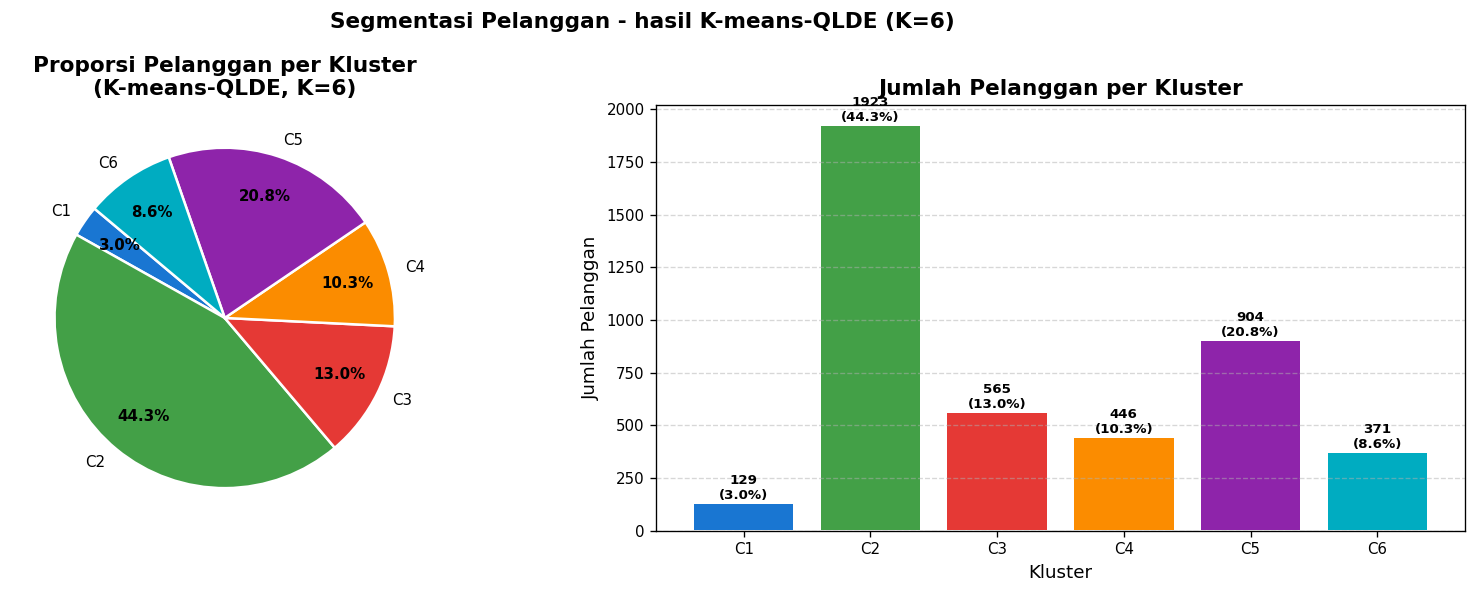

In [27]:
# -----------------------------------------------------------
# 6.6  Pie Chart distribusi kluster
# -----------------------------------------------------------

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Warna konsisten untuk 6 kluster
CLUSTER_COLORS = ['#1976D2', '#43A047', '#E53935', '#FB8C00', '#8E24AA', '#00ACC1']

# Pie chart
wedges, texts, autotexts = axes[0].pie(
    cluster_counts.values,
    labels=[f'C{i}' for i in cluster_counts.index],
    autopct='%1.1f%%',
    colors=CLUSTER_COLORS[:len(cluster_counts)],
    startangle=140,
    pctdistance=0.75,
    wedgeprops={'linewidth': 1.5, 'edgecolor': 'white'}
)
for autotext in autotexts:
    autotext.set_fontsize(9)
    autotext.set_fontweight('bold')
axes[0].set_title('Proporsi Pelanggan per Kluster\n(K-means-QLDE, K=6)',
                  fontweight='bold')

# Bar chart
bars = axes[1].bar(
    [f'C{i}' for i in cluster_counts.index],
    cluster_counts.values,
    color=CLUSTER_COLORS[:len(cluster_counts)],
    edgecolor='white',
    linewidth=1.2
)
axes[1].set_title('Jumlah Pelanggan per Kluster', fontweight='bold')
axes[1].set_xlabel('Kluster')
axes[1].set_ylabel('Jumlah Pelanggan')
axes[1].grid(axis='y', linestyle='--', alpha=0.5)
for bar, cnt, pct in zip(bars, cluster_counts.values, cluster_pct.values):
    axes[1].text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 5,
        f'{cnt}\n({pct}%)',
        ha='center',
        va='bottom',
        fontsize=8,
        fontweight='bold'
    )

plt.suptitle('Segmentasi Pelanggan - hasil K-means-QLDE (K=6)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('cluster_distribution_qlde.png', dpi=120, bbox_inches='tight')
plt.show()


### 6.3 Visualisasi Kluster dalam ruang PCA

Scatter plot 3D dan 2D berikut menunjukkan bagaimana pelanggan tersebar dan terbagi ke dalam 6 kluster di dalam ruang komponen utama - PCA  mereproduksi **Fig. 11** dari paper referensi.


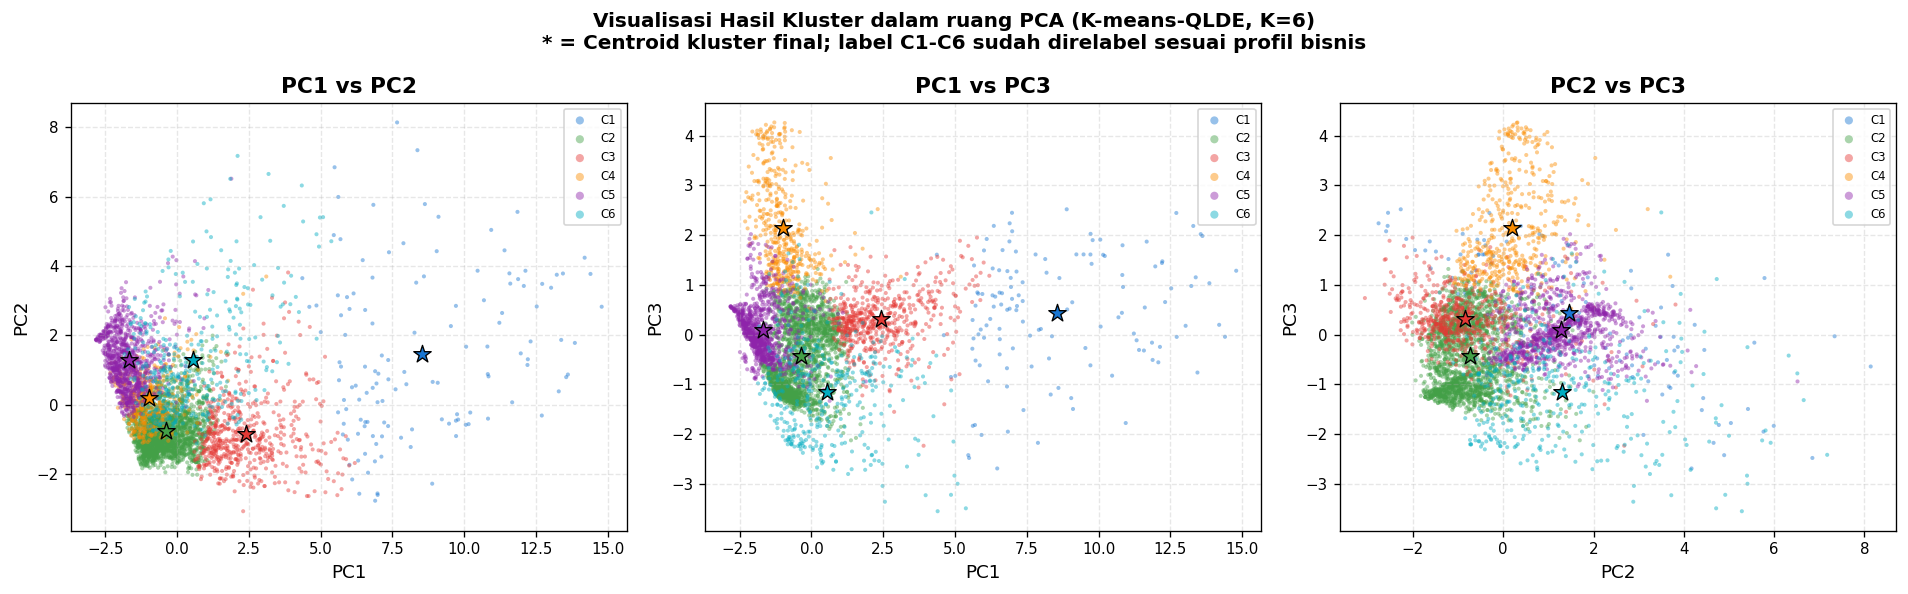

In [28]:
# -----------------------------------------------------------
# 6.7  Scatter plot kluster pada ruang PCA (Fig. 11 paper)
# -----------------------------------------------------------

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Kombinasi pasangan PC
pc_pairs = [
    (0, 1, 'PC1', 'PC2'),
    (0, 2, 'PC1', 'PC3'),
    (1, 2, 'PC2', 'PC3')
]

for ax, (xi, yi, xlabel, ylabel) in zip(axes, pc_pairs):
    for cid, color in zip(range(1, K_OPTIMAL + 1), CLUSTER_COLORS):
        mask = df_pca_clustered['Cluster'].values == cid
        ax.scatter(
            X_pca[mask, xi],
            X_pca[mask, yi],
            c=color,
            s=6,
            alpha=0.45,
            label=f'C{cid}',
            edgecolors='none'
        )

    # Tandai centroid final K-means-QLDE yang sudah diurutkan semantic C1-C6
    for cid_idx, color in enumerate(CLUSTER_COLORS):
        ax.scatter(
            cluster_centers_final[cid_idx, xi],
            cluster_centers_final[cid_idx, yi],
            c=color,
            s=120,
            marker='*',
            edgecolors='black',
            linewidths=0.8,
            zorder=10
        )

    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.set_title(f'{xlabel} vs {ylabel}', fontweight='bold')
    ax.legend(fontsize=7, markerscale=2, loc='upper right')
    ax.grid(linestyle='--', alpha=0.3)

plt.suptitle(
    'Visualisasi Hasil Kluster dalam ruang PCA (K-means-QLDE, K=6)\n'
    '* = Centroid kluster final; label C1-C6 sudah direlabel sesuai profil bisnis',
    fontsize=12,
    fontweight='bold'
)
plt.tight_layout()
plt.savefig('cluster_pca_scatter_qlde.png', dpi=120, bbox_inches='tight')
plt.show()

### 6.4 Profil Kluster  Analisis Karakteristik Setiap Segmen

Untuk memahami makna bisnis dari setiap kluster, kita menghitung **nilai rata-rata fitur asli** (sebelum normalisasi) dari setiap kluster. Ini mereproduksi **Fig. 12** dari paper (radar chart profil kluster).


In [29]:
# -----------------------------------------------------------
# 6.8  Hitung nilai rata-rata fitur per kluster
# -----------------------------------------------------------

cluster_profile = (
    df_cust_clustered
    .groupby('Cluster')[feature_cols]
    .mean()
    .reindex(range(1, K_OPTIMAL + 1))
    .round(2)
)

print('Rata-rata Fitur per Kluster (raw values):')
display(cluster_profile)

if cluster_profile.isna().any(axis=1).any():
    empty_ids = cluster_profile[cluster_profile.isna().any(axis=1)].index.tolist()
    print(f'PERINGATAN: Cluster kosong terdeteksi pada: {empty_ids}')

Rata-rata Fitur per Kluster (raw values):


,Var1,Var2,Var3,Var4,Var5,Var6,Var7,Var8,Var9,Var10,Var11
Cluster,,,,,,,,,,,
1,24.2100,19.2500,7735.1300,14384.4200,1055.9300,179.1900,21.4200,45.8300,0.8000,13.7300,2005.4700
2,47.3300,2.9500,516.0700,842.0400,302.4400,44.9000,34.9500,82.3200,1.0000,0.7500,345.0200
3,24.6800,10.2300,2323.6300,3884.4400,444.8200,156.6400,38.8900,63.5800,0.9800,5.2900,631.4100
4,65.5100,2.2700,436.9700,684.1400,302.5600,43.8300,187.7800,256.4100,0.9900,0.8800,306.7000
5,257.0800,1.4900,209.6700,386.2800,268.7900,22.7200,13.0300,270.2300,0.9700,0.5900,286.9000
6,85.1200,2.9400,887.7000,1648.4600,645.5900,52.2700,44.4700,129.6600,0.0600,1.4800,733.9200


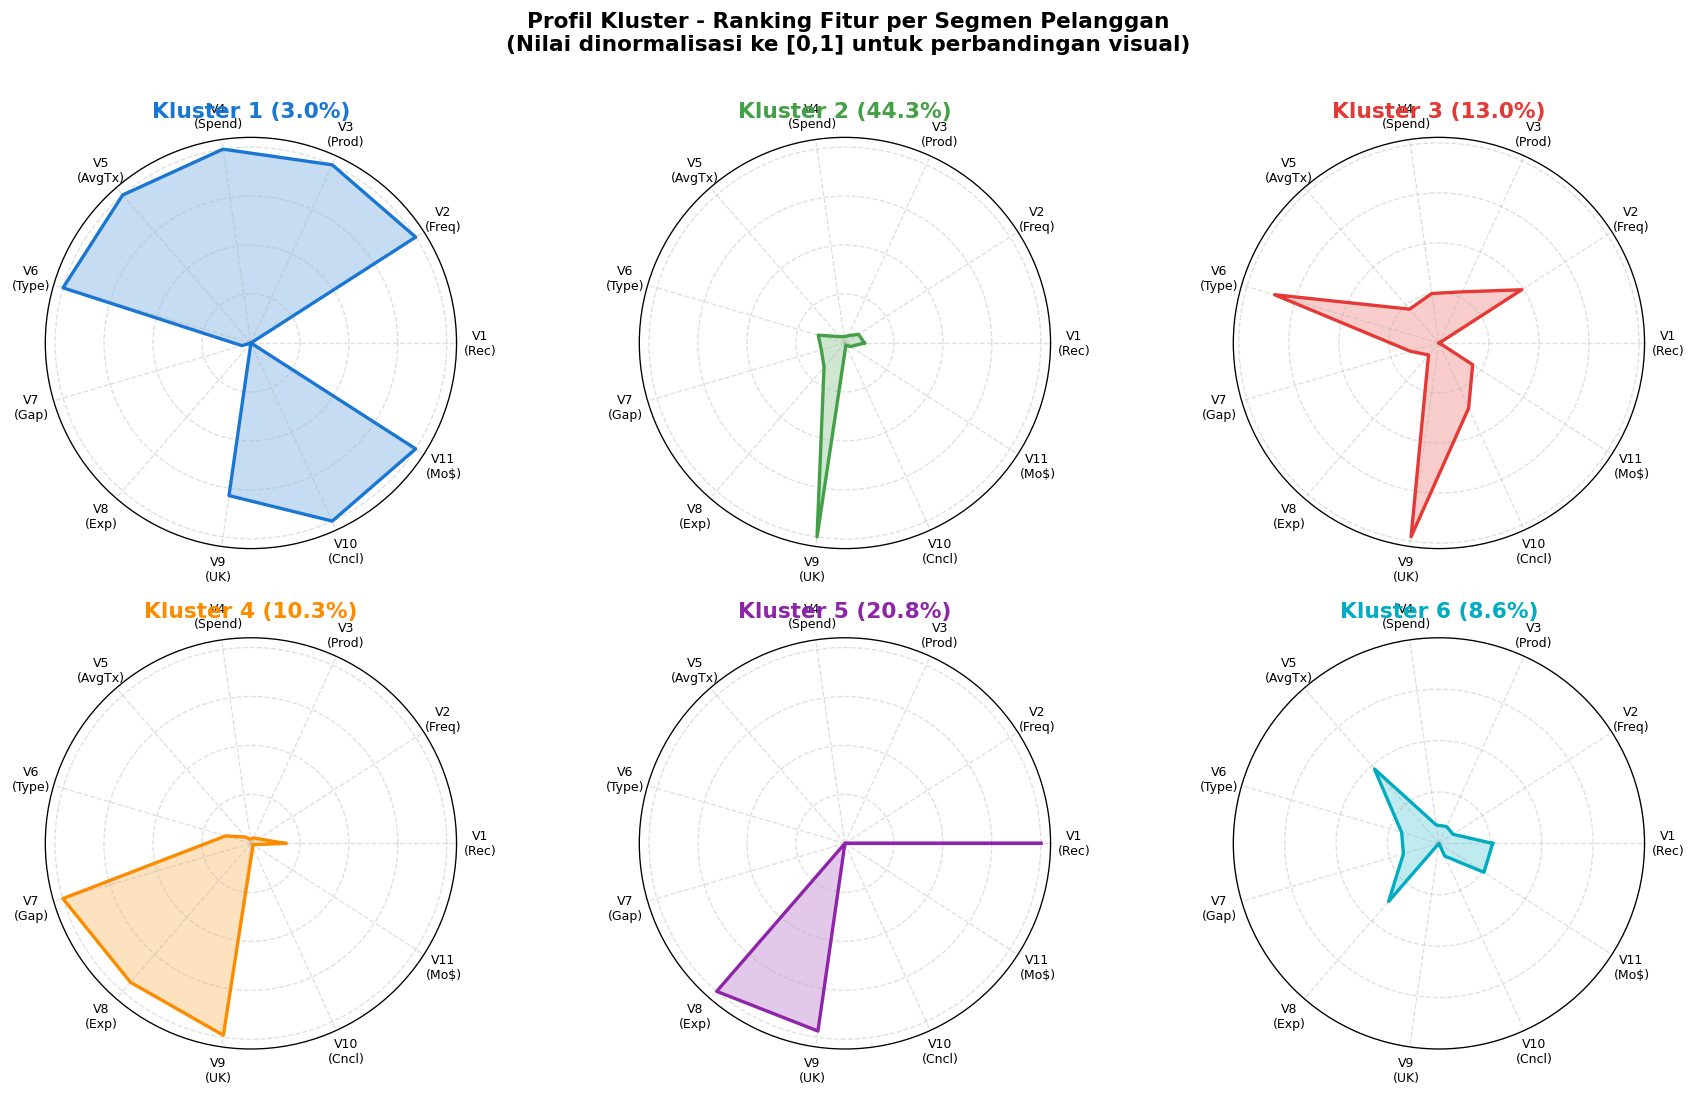

In [30]:
# -----------------------------------------------------------
# 6.9  Normalisasi profil kluster untuk visualisasi radar chart
#  (nilai dinormalisasi ke rentang [0,1] per fitur)
# -----------------------------------------------------------

profile_norm = minmax_profile(cluster_profile).fillna(0.5)

# Radar Chart
angles = np.linspace(0, 2 * np.pi, len(feature_cols), endpoint=False).tolist()
angles += angles[:1]  # tutup lingkaran

var_short = [
    'V1\n(Rec)', 'V2\n(Freq)', 'V3\n(Prod)',
    'V4\n(Spend)', 'V5\n(AvgTx)', 'V6\n(Type)',
    'V7\n(Gap)', 'V8\n(Exp)', 'V9\n(UK)',
    'V10\n(Cncl)', 'V11\n(Mo$)'
]

fig, axes = plt.subplots(2, 3, figsize=(15, 9), subplot_kw=dict(polar=True))
axes_flat = axes.flatten()

for idx, cid in enumerate(range(1, K_OPTIMAL + 1)):
    ax = axes_flat[idx]
    color = CLUSTER_COLORS[idx]
    row = profile_norm.loc[cid].values.tolist()
    row += row[:1]

    ax.plot(angles, row, color=color, linewidth=2)
    ax.fill(angles, row, color=color, alpha=0.25)
    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(var_short, fontsize=7.5)
    ax.set_yticks([0.25, 0.5, 0.75, 1.0])
    ax.set_yticklabels(['', '', '', ''], fontsize=6)
    ax.set_title(
        f'Kluster {cid} ({cluster_pct.loc[cid]:.1f}%)',
        fontweight='bold',
        color=color,
        pad=12
    )
    ax.grid(linestyle='--', alpha=0.4)

plt.suptitle(
    'Profil Kluster - Ranking Fitur per Segmen Pelanggan\n'
    '(Nilai dinormalisasi ke [0,1] untuk perbandingan visual)',
    fontsize=13,
    fontweight='bold',
    y=1.01
)
plt.tight_layout()
plt.savefig('cluster_radar_qlde.png', dpi=120, bbox_inches='tight')
plt.show()

In [31]:
# -----------------------------------------------------------
# 6.10  Tabel interpretasi bisnis setiap kluster
# -----------------------------------------------------------

profile_descriptions = {
    1: {
        'Profil Bisnis': 'Premium / High-Value Customers',
        'Implikasi Strategi Marketing': (
            'Pengeluaran total/bulanan tinggi; cocok untuk loyalty program, VIP offer, dan retensi pelanggan bernilai tinggi.'
        )
    },
    2: {
        'Profil Bisnis': 'Price-Sensitive / Mass Customers',
        'Implikasi Strategi Marketing': (
            'Volume pembelian tinggi tetapi lebih sensitif harga; cocok untuk diskon, bundling, dan promo kuantitas.'
        )
    },
    3: {
        'Profil Bisnis': 'High-Expectation Customers (High Cancel)',
        'Implikasi Strategi Marketing': (
            'Frekuensi pembatalan tinggi; perlu detail produk lebih jelas, review, estimasi pengiriman, dan proses checkout yang minim risiko.'
        )
    },
    4: {
        'Profil Bisnis': 'UK-Loyal Customers',
        'Implikasi Strategi Marketing': (
            'Dominan/kuat dari UK; cocok untuk personalisasi regional, rekomendasi produk lokal, dan strategi retensi.'
        )
    },
    5: {
        'Profil Bisnis': 'Cautious / Planned Buyers',
        'Implikasi Strategi Marketing': (
            'Interval pembelian relatif panjang/terencana; cocok untuk reminder, seasonal campaign, dan promo akhir pekan.'
        )
    },
    6: {
        'Profil Bisnis': 'Balanced / Moderate Customers',
        'Implikasi Strategi Marketing': (
            'Tidak ekstrem pada satu indikator; cocok untuk campaign umum, cross-selling ringan, dan diversifikasi promosi.'
        )
    }
}

var_meaning = {
    'Var1': 'Recency',
    'Var2': 'Frequency',
    'Var3': 'Total Produk',
    'Var4': 'Total Pengeluaran',
    'Var5': 'Avg Biaya/Transaksi',
    'Var6': 'Jumlah Tipe Produk',
    'Var7': 'Avg Jarak Pembelian',
    'Var8': 'Estimasi Beli Berikutnya',
    'Var9': 'UK Flag',
    'Var10': 'Cancel Frequency',
    'Var11': 'Avg Pengeluaran/Bulan'
}

interpretation_rows = []
for cid in range(1, K_OPTIMAL + 1):
    top_vars = profile_norm.loc[cid].sort_values(ascending=False).head(3)
    top_desc = ', '.join([f'{v} ({var_meaning[v]})' for v in top_vars.index])

    interpretation_rows.append({
        'Kluster': f'C{cid}',
        'Proporsi': f'{cluster_pct.loc[cid]:.1f}%',
        'Profil Bisnis': profile_descriptions[cid]['Profil Bisnis'],
        'Fitur Dominan': top_desc,
        'Implikasi Strategi Marketing': profile_descriptions[cid]['Implikasi Strategi Marketing']
    })

cluster_interpretation = pd.DataFrame(interpretation_rows)

print('Tabel Interpretasi Bisnis Cluster')
print('Catatan: C1-C6 direlabel berdasarkan profil bisnis setelah distribusi cluster divalidasi.')
print('Label KMeans/QLDE bersifat arbitrary; nomor C1-C6 tidak otomatis sama dengan raw cluster.\n')
display(cluster_interpretation)

print('\nVersi teks:')
print(cluster_interpretation.to_string(index=False))

# Perbandingan singkat dengan proporsi paper Fig. 10
paper_pct = pd.Series({1: 9.7, 2: 47.9, 3: 7.2, 4: 6.6, 5: 21.3, 6: 7.3})
comparison_pct = pd.DataFrame({
    'Cluster': [f'C{i}' for i in range(1, K_OPTIMAL + 1)],
    'Notebook (%)': [float(cluster_pct.loc[i]) for i in range(1, K_OPTIMAL + 1)],
    'Paper Fig.10 (%)': [paper_pct.loc[i] for i in range(1, K_OPTIMAL + 1)],
    'Selisih': [float(cluster_pct.loc[i]) - paper_pct.loc[i] for i in range(1, K_OPTIMAL + 1)]
})
print('\nPerbandingan proporsi dengan paper Fig. 10:')
display(comparison_pct)

print('\nCatatan penting: angka tidak wajib identik karena implementasi Python ini adalah reimplementasi/simplifikasi. Yang perlu dihindari adalah cluster kosong atau cluster ekstrem kecil (<3%).')


Tabel Interpretasi Bisnis Cluster
Catatan: C1-C6 direlabel berdasarkan profil bisnis setelah distribusi cluster divalidasi.
Label KMeans/QLDE bersifat arbitrary; nomor C1-C6 tidak otomatis sama dengan raw cluster.



,Kluster,Proporsi,Profil Bisnis,Fitur Dominan,Implikasi Strategi Marketing
0,C1,3.0%,Premium / High-Value Customers,"Var2 (Frequency), Var3 (Total Produk), Var4 (T...",Pengeluaran total/bulanan tinggi; cocok untuk ...
1,C2,44.3%,Price-Sensitive / Mass Customers,"Var9 (UK Flag), Var8 (Estimasi Beli Berikutnya...",Volume pembelian tinggi tetapi lebih sensitif ...
2,C3,13.0%,High-Expectation Customers (High Cancel),"Var9 (UK Flag), Var6 (Jumlah Tipe Produk), Var...",Frekuensi pembatalan tinggi; perlu detail prod...
3,C4,10.3%,UK-Loyal Customers,"Var7 (Avg Jarak Pembelian), Var9 (UK Flag), Va...",Dominan/kuat dari UK; cocok untuk personalisas...
4,C5,20.8%,Cautious / Planned Buyers,"Var1 (Recency), Var8 (Estimasi Beli Berikutnya...",Interval pembelian relatif panjang/terencana; ...
5,C6,8.6%,Balanced / Moderate Customers,"Var5 (Avg Biaya/Transaksi), Var8 (Estimasi Bel...",Tidak ekstrem pada satu indikator; cocok untuk...



Versi teks:
Kluster Proporsi                            Profil Bisnis                                                               Fitur Dominan                                                                                                      Implikasi Strategi Marketing
     C1     3.0%           Premium / High-Value Customers             Var2 (Frequency), Var3 (Total Produk), Var4 (Total Pengeluaran)                  Pengeluaran total/bulanan tinggi; cocok untuk loyalty program, VIP offer, dan retensi pelanggan bernilai tinggi.
     C2    44.3%         Price-Sensitive / Mass Customers  Var9 (UK Flag), Var8 (Estimasi Beli Berikutnya), Var6 (Jumlah Tipe Produk)                           Volume pembelian tinggi tetapi lebih sensitif harga; cocok untuk diskon, bundling, dan promo kuantitas.
     C3    13.0% High-Expectation Customers (High Cancel)                 Var9 (UK Flag), Var6 (Jumlah Tipe Produk), Var2 (Frequency) Frekuensi pembatalan tinggi; perlu detail produk lebih jelas,

,Cluster,Notebook (%),Paper Fig.10 (%),Selisih
0,C1,3.0000,9.7000,-6.7000
1,C2,44.3000,47.9000,-3.6000
2,C3,13.0000,7.2000,5.8000
3,C4,10.3000,6.6000,3.7000
4,C5,20.8000,21.3000,-0.5000
5,C6,8.6000,7.3000,1.3000



Catatan penting: angka tidak wajib identik karena implementasi Python ini adalah reimplementasi/simplifikasi. Yang perlu dihindari adalah cluster kosong atau cluster ekstrem kecil (<3%).


### Ringkasan Hasil Bagian 6 - K-means-QLDE

| Metrik | Nilai Notebook | Catatan |
|--------|----------------|---------|
| Jumlah kluster optimal | **K = 6** | Dipilih dari Elbow Method seperti paper |
| Input clustering | **6 komponen PCA** | PCA dari 11 fitur Var1-Var11 |
| Objective QLDE | **SSE/Inertia** | Semakin kecil semakin baik |
| Optimizer | **Q-learning + Differential Evolution** | Q-table mengatur adaptasi scaling factor `F` |
| Final clustering | **K-Means dengan centroid hasil QLDE** | Lebih dekat ke metode utama paper |
| Classifier validasi | **Decision Tree** | Disederhanakan dari 4 classifier paper |

**Interpretasi metodologis:**  
Bagian ini sudah tidak lagi memakai K-Means standar sebagai model final. K-Means baseline tetap dihitung hanya sebagai pembanding, sedangkan label cluster akhir diambil dari **K-means-QLDE**.


---

## Bagian 7 - Validasi Klasifikasi menggunakan Decision Tree

### Tujuan Bagian Ini
Setelah proses **K-means-QLDE** menghasilkan label segmen pelanggan, tahap ini memvalidasi apakah label cluster dapat dipelajari oleh model klasifikasi.

Paper menggunakan 4 metode klasifikasi: **KSVM, Decision Tree, AdaBoost, dan ANN**. Pada notebook ini, validasi cukup menggunakan **Decision Tree (DT)** sesuai kebutuhan tugas.

Pipeline:
1. Split data: 80% train / 20% test.
2. Input classifier: 6 komponen PCA.
3. Target classifier: label cluster hasil K-means-QLDE.
4. 5-Fold Cross Validation untuk memilih `max_depth`.
5. Evaluasi akhir pada test set.


In [32]:
# ============================================================
#  Bagian 7 - Validasi Klasifikasi: Decision Tree
# ============================================================

# - Import Library klasifikasi
from sklearn.tree  import DecisionTreeClassifier, export_text, plot_tree
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.metrics  import (accuracy_score, classification_report,
  confusion_matrix, ConfusionMatrixDisplay)

print(' Library klasifikasi berhasil diimpor.')


 Library klasifikasi berhasil diimpor.


### 7.1 Persiapan Data  Train/Test Split (80:20)

Input fitur yang digunakan untuk klasifikasi adalah **6 komponen PCA** (X_pca), yaitu representasi dimensi-rendah dari 11 fitur asli  konsisten dengan paper yang menyatakan *"the first six principal components were used as the input of the models"*.

Target label adalah **nomor kluster (16)** hasil K-Means pada Bagian 6.


In [33]:
# -----------------------------------------------------------
# 7.1  Persiapan fitur dan label
# -----------------------------------------------------------

X_cls = X_pca                 # 6 komponen PCA sebagai input fitur
y_cls = cluster_labels        # Label kluster hasil K-means-QLDE (0-5)

# Stratified split butuh minimal 2 sampel pada setiap kelas.
label_counts = pd.Series(y_cls).value_counts().sort_index()
can_stratify = label_counts.min() >= 2
stratify_arg = y_cls if can_stratify else None

if not can_stratify:
    print('PERINGATAN: Ada cluster dengan anggota < 2, stratified split dinonaktifkan.')
    print('Distribusi label:', label_counts.to_dict())

# Train-test split: 80% train, 20% test sesuai paper
X_train, X_test, y_train, y_test = train_test_split(
    X_cls,
    y_cls,
    test_size=0.20,
    random_state=RANDOM_SEED,
    stratify=stratify_arg
)

print('Pembagian Dataset (Train/Test Split 80:20):')
print('-' * 45)
print(f'  Total sampel  : {len(X_cls):>6,}')
print(f'  Training set  : {len(X_train):>6,}  ({len(X_train)/len(X_cls)*100:.1f}%)')
print(f'  Test set      : {len(X_test):>6,}  ({len(X_test)/len(X_cls)*100:.1f}%)')
print('-' * 45)
print('Distribusi kelas training:')
for lbl in sorted(np.unique(y_train)):
    cnt = (y_train == lbl).sum()
    print(f'  Cluster {lbl+1}: {cnt:4d} ({cnt/len(y_train)*100:.1f}%)')


Pembagian Dataset (Train/Test Split 80:20):
---------------------------------------------
  Total sampel  :  4,338
  Training set  :  3,470  (80.0%)
  Test set      :    868  (20.0%)
---------------------------------------------
Distribusi kelas training:
  Cluster 1:  103 (3.0%)
  Cluster 2: 1538 (44.3%)
  Cluster 3:  452 (13.0%)
  Cluster 4:  357 (10.3%)
  Cluster 5:  723 (20.8%)
  Cluster 6:  297 (8.6%)


### 7.2 Decision Tree Baseline (max_depth=2)

Sebelum melakukan hyperparameter tuning, model Decision Tree dilatih terlebih dahulu sebagai **baseline awal** dengan parameter sederhana `max_depth=2`. Tujuannya adalah menetapkan **titik pembanding (baseline)** yang menggambarkan performa model tanpa optimasi.

Pemilihan `max_depth=2` merupakan konfigurasi paling sederhana yang masih menghasilkan pohon keputusan bermakna  cukup untuk membuktikan apakah segmentasi - K-Means *dapat dipelajari*, namun diharapkan masih **underfitting** sehingga ada ruang peningkatan yang jelas melalui tuning.

In [34]:
# -----------------------------------------------------------
# 7.2  Decision Tree BASELINE  max_depth = 2
# -----------------------------------------------------------

dt_baseline = DecisionTreeClassifier(
  max_depth=2,
  criterion='gini',
  random_state=RANDOM_SEED
)
dt_baseline.fit(X_train, y_train)

y_pred_base_train = dt_baseline.predict(X_train)
y_pred_base_test  = dt_baseline.predict(X_test)

base_train_acc = accuracy_score(y_train, y_pred_base_train)
base_test_acc  = accuracy_score(y_test,  y_pred_base_test)

print('=' * 55)
print('  Decision Tree BASELINE  (max_depth = 2)')
print('=' * 55)
print(f'  Training Accuracy : {base_train_acc*100:>8.2f}%')
print(f'  Test Set Accuracy : {base_test_acc*100:>8.2f}%  <- Metrik Utama')
print('=' * 55)
print()
if base_test_acc < 0.95:
  print('  Indikasi UNDERFITTING  model terlalu sederhana.')
  print('  Perlu hyperparameter tuning untuk meningkatkan performa.')
else:
  print('  Baseline sudah cukup baik (>= 95%).')

# Classification report singkat baseline
print()
print('  Classification Report (Baseline):')
actual_labels_base = sorted(list(set(y_test)))
cluster_names_base = [f'Cluster {l+1}' for l in actual_labels_base]
print(classification_report(
  y_test, y_pred_base_test,
  labels=actual_labels_base,
  target_names=cluster_names_base,
  zero_division=0
))

# Simpan untuk tabel komparasi akhir
BASELINE_TRAIN_ACC = base_train_acc
BASELINE_TEST_ACC  = base_test_acc


  Decision Tree BASELINE  (max_depth = 2)
  Training Accuracy :    75.24%
  Test Set Accuracy :    73.96%  <- Metrik Utama

  Indikasi UNDERFITTING  model terlalu sederhana.
  Perlu hyperparameter tuning untuk meningkatkan performa.

  Classification Report (Baseline):
              precision    recall  f1-score   support

   Cluster 1       0.00      0.00      0.00        26
   Cluster 2       0.67      0.95      0.78       385
   Cluster 3       0.76      0.34      0.47       113
   Cluster 4       0.83      0.98      0.90        89
   Cluster 5       0.90      0.84      0.87       181
   Cluster 6       0.00      0.00      0.00        74

    accuracy                           0.74       868
   macro avg       0.53      0.52      0.50       868
weighted avg       0.67      0.74      0.68       868



### 7.3 Hyperparameter Tuning dengan 5-Fold Cross Validation

Untuk menemukan kedalaman pohon (`max_depth`) yang optimal, dilakukan **5-Fold Cross Validation** pada training set untuk berbagai nilai `max_depth`. Ini mereproduksi metodologi paper yang menggunakan cross-validation untuk menyetel hyperparameter model.


In [35]:
# -----------------------------------------------------------
# 7.3  Hyperparameter Tuning: Cari max_depth optimal via CV
# -----------------------------------------------------------

cv_strategy = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_SEED)

depth_range  = range(2, 21)
cv_mean_scores = []
cv_std_scores  = []

print(' Cross-Validation (5-fold) untuk pencarian max_depth ...')
print('' * 58)
print(f'  {"max_depth":>10}  {"CV Mean Acc (%)":>16}  {"Std Dev":>10}')
print('' * 58)

for depth in depth_range:
  dt = DecisionTreeClassifier(
  max_depth=depth,
  criterion='gini',
  random_state=RANDOM_SEED
  )
  cv_scores = cross_val_score(dt, X_train, y_train,
  cv=cv_strategy, scoring='accuracy')
  cv_mean_scores.append(cv_scores.mean())
  cv_std_scores.append(cv_scores.std())
  marker = '  Best' if cv_scores.mean() == max(cv_mean_scores) else ''
  print(f'  {depth:>10}  {cv_scores.mean()*100:>15.3f}%  +-{cv_scores.std()*100:.3f}%{marker}')

print('' * 58)

best_depth = depth_range.start + np.argmax(cv_mean_scores)
best_cv_acc = max(cv_mean_scores)
print(f'\n max_depth terbaik  : {best_depth}')
print(f'  CV Accuracy terbaik  : {best_cv_acc*100:.3f}%')


 Cross-Validation (5-fold) untuk pencarian max_depth ...

   max_depth   CV Mean Acc (%)     Std Dev

           2           75.130%  +-1.033%  Best
           3           85.216%  +-1.201%  Best
           4           91.556%  +-1.291%  Best
           5           92.680%  +-1.045%  Best
           6           94.265%  +-0.634%  Best
           7           94.294%  +-0.661%  Best
           8           94.870%  +-0.923%  Best
           9           95.043%  +-1.294%  Best
          10           95.072%  +-1.214%  Best
          11           95.101%  +-0.934%  Best
          12           95.072%  +-1.106%
          13           95.072%  +-1.168%
          14           95.187%  +-1.111%  Best
          15           94.813%  +-1.279%
          16           94.986%  +-1.368%
          17           94.755%  +-1.252%
          18           94.755%  +-1.252%
          19           94.755%  +-1.252%
          20           94.755%  +-1.252%


 max_depth terbaik  : 14
  CV Accuracy terbaik  : 9

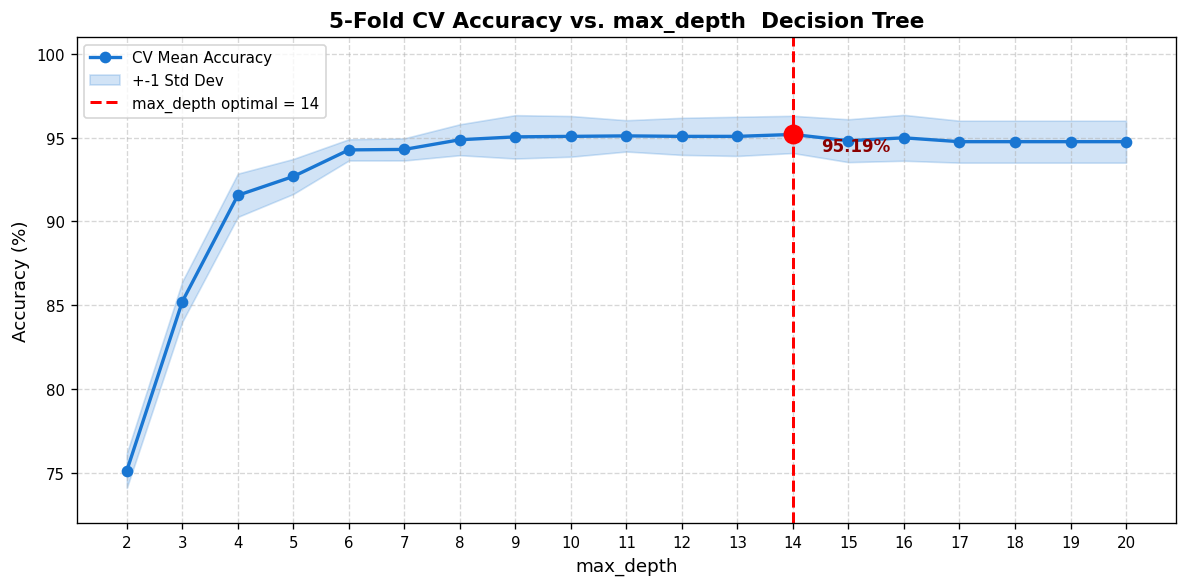

In [36]:
# -----------------------------------------------------------
# 7.4  Visualisasi CV Accuracy Accuracy vs max_depth
# -----------------------------------------------------------

fig, ax = plt.subplots(figsize=(10, 5))
depth_list = list(depth_range)

ax.plot(depth_list, [s * 100 for s in cv_mean_scores],
  marker='o', color='#1976D2', linewidth=2, markersize=6,
  label='CV Mean Accuracy')
ax.fill_between(depth_list,
  [(m - s) * 100 for m, s in zip(cv_mean_scores, cv_std_scores)],
  [(m + s) * 100 for m, s in zip(cv_mean_scores, cv_std_scores)],
  alpha=0.2, color='#1976D2', label='+-1 Std Dev')

ax.axvline(x=best_depth, color='red', linestyle='--', linewidth=1.8,
  label=f'max_depth optimal = {best_depth}')
ax.scatter([best_depth], [best_cv_acc * 100],
  color='red', s=120, zorder=5)
ax.annotate(f'{best_cv_acc*100:.2f}%',
  xy=(best_depth, best_cv_acc * 100),
  xytext=(best_depth + 0.5, best_cv_acc * 100 - 1),
  fontsize=10, color='darkred', fontweight='bold')

ax.set_title('5-Fold CV Accuracy vs. max_depth  Decision Tree', fontweight='bold')
ax.set_xlabel('max_depth')
ax.set_ylabel('Accuracy (%)')
ax.set_xticks(depth_list)
ax.legend(fontsize=9)
ax.grid(linestyle='--', alpha=0.5)
ax.set_ylim([ax.get_ylim()[0] - 1, 101])
plt.tight_layout()
plt.savefig('cv_accuracy_depth.png', dpi=120, bbox_inches='tight')
plt.show()


### 7.4 Pelatihan Model Final dan Evaluasi pada Test Set

Model Decision Tree final dilatih menggunakan kedalaman optimal yang ditemukan melalui CV, lalu dievaluasi pada **test set (20% data)** yang belum pernah dilihat model.


In [37]:
# -----------------------------------------------------------
# 7.5  Latih Decision Tree final dengan max_depth optimal
# -----------------------------------------------------------

dt_final = DecisionTreeClassifier(
  max_depth=best_depth,
  criterion='gini',
  random_state=RANDOM_SEED
)
dt_final.fit(X_train, y_train)

#  Prediksi & akurasi
y_pred_train = dt_final.predict(X_train)
y_pred_test  = dt_final.predict(X_test)

train_acc = accuracy_score(y_train, y_pred_train)
test_acc  = accuracy_score(y_test, y_pred_test)

print(' Performa Model Decision Tree Final:')
print('' * 50)
print(f'  Validation Mean CV Accuracy : {best_cv_acc*100:>8.3f}%')
print(f'  Training Set Accuracy  : {train_acc*100:>8.3f}%')
print(f'  TEST SET ACCURACY  : {test_acc*100:>8.3f}%  Metrik utama')
print('' * 50)

if test_acc >= 0.95:
  print(f'\n Akurasi  95% terpenuhi  konsisten dengan target paper (>95%).')
else:
  print(f'\n  Akurasi < 95%. Perlu eksplorasi hyperparameter lebih lanjut.')


 Performa Model Decision Tree Final:

  Validation Mean CV Accuracy :   95.187%
  Training Set Accuracy  :   99.856%
  TEST SET ACCURACY  :   94.009%  Metrik utama


  Akurasi < 95%. Perlu eksplorasi hyperparameter lebih lanjut.


In [38]:
# -----------------------------------------------------------
# 7.6  Classification Report (Precision, Recall, F1 per kluster)
# -----------------------------------------------------------

# Ambil label unik dari gabungan train+test
actual_labels = sorted(np.unique(np.concatenate([y_train, y_test])))
cluster_names = [f'Cluster {lbl+1}' for lbl in actual_labels]

print('Classification Report - Decision Tree (Test Set):\n')
print(classification_report(
    y_test,
    y_pred_test,
    labels=actual_labels,
    target_names=cluster_names,
    zero_division=0
))


Classification Report - Decision Tree (Test Set):

              precision    recall  f1-score   support

   Cluster 1       0.96      0.92      0.94        26
   Cluster 2       0.95      0.97      0.96       385
   Cluster 3       0.88      0.88      0.88       113
   Cluster 4       0.95      0.92      0.94        89
   Cluster 5       0.95      0.93      0.94       181
   Cluster 6       0.95      0.93      0.94        74

    accuracy                           0.94       868
   macro avg       0.94      0.93      0.93       868
weighted avg       0.94      0.94      0.94       868



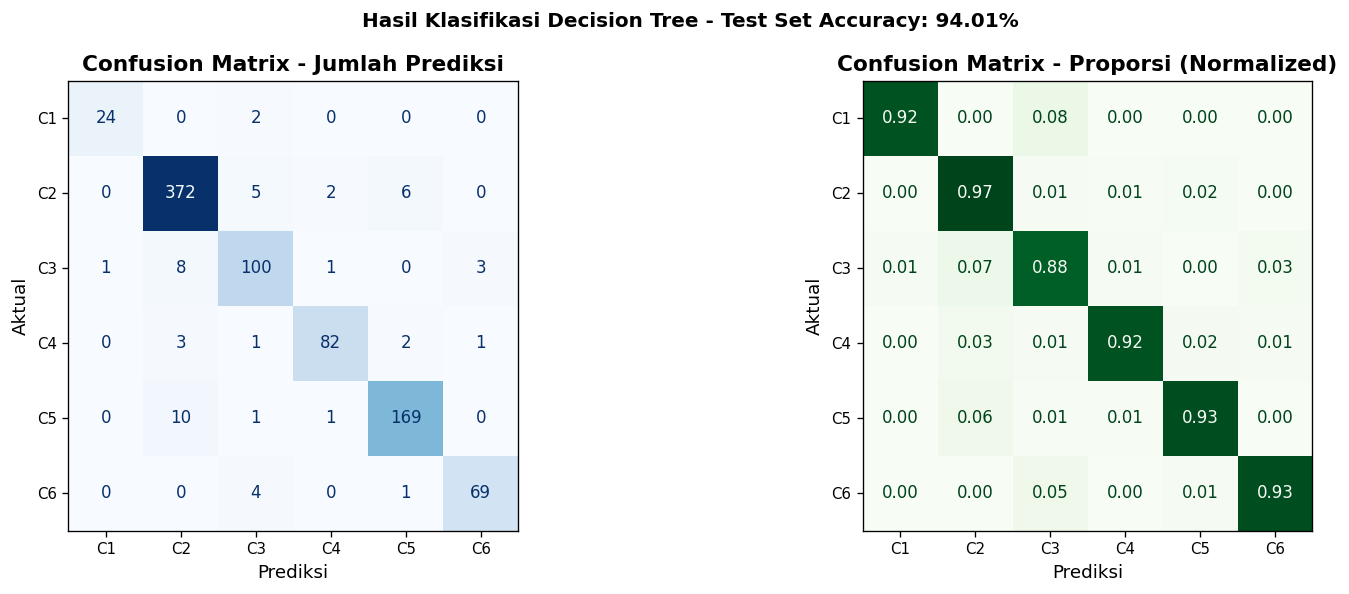

In [39]:
# -----------------------------------------------------------
# 7.7  Confusion Matrix
# -----------------------------------------------------------

display_label_names = [f'C{lbl+1}' for lbl in actual_labels]

cm = confusion_matrix(y_test, y_pred_test, labels=actual_labels)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Confusion Matrix (counts)
disp_count = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=display_label_names
)
disp_count.plot(ax=axes[0], colorbar=False, cmap='Blues', values_format='d')
axes[0].set_title('Confusion Matrix - Jumlah Prediksi', fontweight='bold')
axes[0].set_xlabel('Prediksi')
axes[0].set_ylabel('Aktual')

# Confusion Matrix (normalized / persentase)
row_sums = cm.sum(axis=1, keepdims=True)
cm_norm = np.divide(
    cm.astype(float),
    row_sums,
    out=np.zeros_like(cm, dtype=float),
    where=row_sums != 0
)

disp_norm = ConfusionMatrixDisplay(
    confusion_matrix=cm_norm,
    display_labels=display_label_names
)
disp_norm.plot(ax=axes[1], colorbar=False, cmap='Greens', values_format='.2f')
axes[1].set_title('Confusion Matrix - Proporsi (Normalized)', fontweight='bold')
axes[1].set_xlabel('Prediksi')
axes[1].set_ylabel('Aktual')

plt.suptitle(f'Hasil Klasifikasi Decision Tree - Test Set Accuracy: {test_acc*100:.2f}%',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=120, bbox_inches='tight')
plt.show()


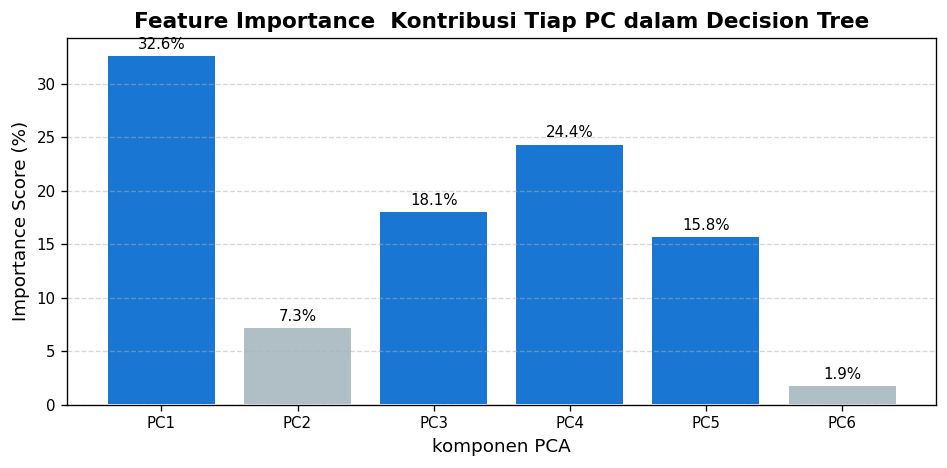


 Feature Importance Detail:
  PC1: 32.63%  
  PC4: 24.39%  
  PC3: 18.09%  
  PC5: 15.76%  
  PC2:  7.28%  
  PC6:  1.85%  


In [40]:
# -----------------------------------------------------------
# 7.8  Feature Importance (kontribusi PC terhadap klasifikasi)
# -----------------------------------------------------------

importance_scores = dt_final.feature_importances_
pc_names = [f'PC{i+1}' for i in range(N_PCA_COMPONENTS)]

fig, ax = plt.subplots(figsize=(8, 4))
colors_imp = ['#1976D2' if imp >= 0.1 else '#B0BEC5' for imp in importance_scores]
bars = ax.bar(pc_names, importance_scores * 100, color=colors_imp,
  edgecolor='white', linewidth=1.2)
ax.set_title('Feature Importance  Kontribusi Tiap PC dalam Decision Tree',
  fontweight='bold')
ax.set_xlabel('komponen PCA')
ax.set_ylabel('Importance Score (%)')
ax.grid(axis='y', linestyle='--', alpha=0.5)
for bar, imp in zip(bars, importance_scores):
  ax.text(bar.get_x() + bar.get_width() / 2,
  bar.get_height() + 0.3,
  f'{imp*100:.1f}%', ha='center', va='bottom', fontsize=9)
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=120, bbox_inches='tight')
plt.show()

print('\n Feature Importance Detail:')
for pc, imp in sorted(zip(pc_names, importance_scores), key=lambda x: -x[1]):
  bar_vis = '' * int(imp * 50)
  print(f'  {pc}: {imp*100:5.2f}%  {bar_vis}')


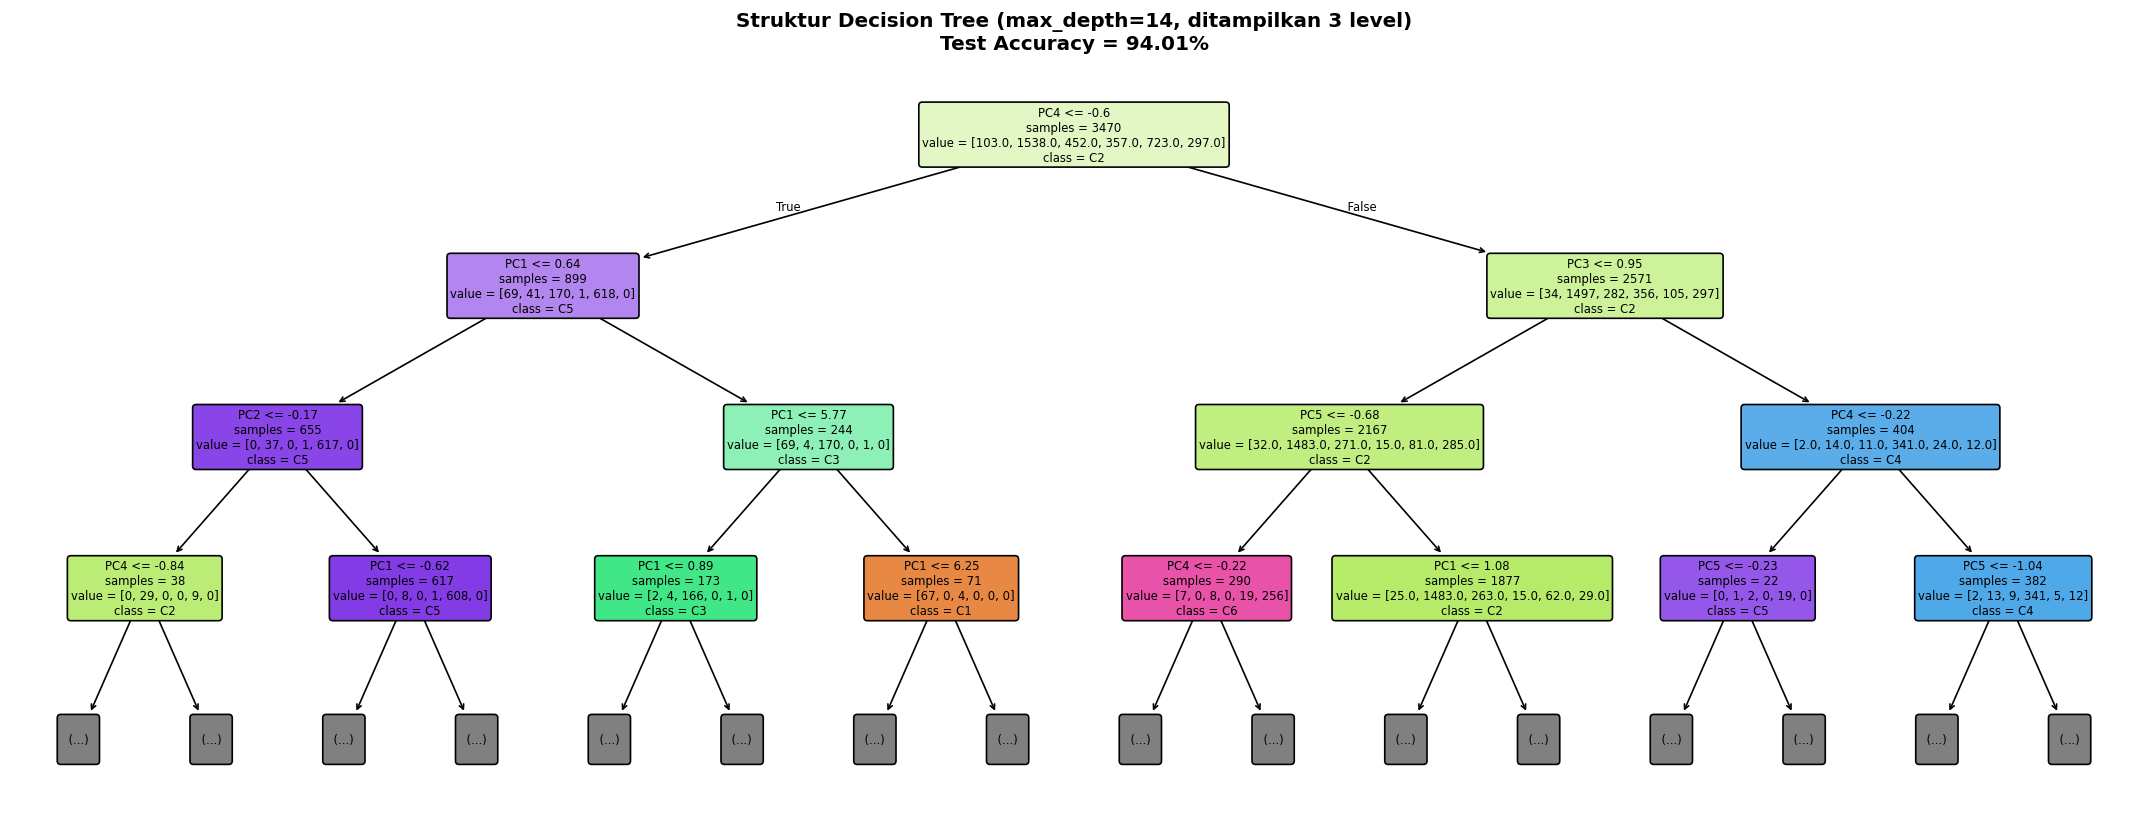

Visualisasi Decision Tree tersimpan.


In [41]:
# -----------------------------------------------------------
# 7.9  Visualisasi struktur Decision Tree (kedalaman 3 level)
# -----------------------------------------------------------

fig, ax = plt.subplots(figsize=(18, 7))

plot_tree(
    dt_final,
    max_depth=3,  # Tampilkan hanya 3 level teratas agar terbaca
    feature_names=pc_names,
    class_names=[f'C{int(lbl)+1}' for lbl in dt_final.classes_],
    filled=True,
    rounded=True,
    ax=ax,
    fontsize=7,
    impurity=False,
    precision=2
)
ax.set_title(
    f'Struktur Decision Tree (max_depth={best_depth}, ditampilkan 3 level)\n'
    f'Test Accuracy = {test_acc*100:.2f}%',
    fontsize=12,
    fontweight='bold'
)
plt.tight_layout()
plt.savefig('decision_tree_structure.png', dpi=100, bbox_inches='tight')
plt.show()
print('Visualisasi Decision Tree tersimpan.')


### Ringkasan Hasil Bagian 7 - Validasi Decision Tree

| Metrik | Nilai |
|--------|-------|
| 5-Fold CV Mean Accuracy (train) | lihat output sel 7.3 |
| Training Accuracy | lihat output sel 7.5 |
| **Test Set Accuracy** | **lihat output sel 7.5** |
| Jumlah Fitur Input | 6 (PC1-PC6) |
| Target | Label cluster hasil K-means-QLDE |
| Algoritma | Decision Tree (criterion=gini) |
| max_depth | dipilih dari CV |

**Interpretasi:**
- Akurasi Decision Tree >= 95% menunjukkan bahwa label hasil K-means-QLDE dapat dipelajari dengan baik oleh model supervised.
- Notebook ini tetap valid walaupun classifier-nya hanya DT, karena DT termasuk salah satu classifier yang digunakan pada paper.
- Perbedaannya: paper juga menambahkan KSVM, AdaBoost, dan ANN; notebook ini menyederhanakan validasi hanya dengan DT.

---
## Kesimpulan Akhir Notebook

| Tahap | Status | Keterangan |
|-------|--------|------------|
| Load Dataset | Partial | UCI Online Retail digunakan sebagai asumsi ekuivalen dengan dataset paper |
| Feature Engineering | Sesuai | 11 fitur RFM-like (Var1-Var11) + clipping outlier p1-p99 untuk stabilitas cluster |
| Z-Score Normalization | Sesuai | StandardScaler |
| PCA (6 komponen) | Sesuai | 6 PC mempertahankan >=90% variance |
| K-means-QLDE | Sesuai arah paper | Q-learning + Differential Evolution mengoptimasi centroid/SSE |
| Validasi Decision Tree | Sesuai sebagian | DT saja, tanpa KSVM/AdaBoost/ANN |

**Kesimpulan:** Notebook ini sudah disesuaikan lebih dekat dengan metode utama paper karena model final clustering menggunakan **K-means-QLDE**, bukan K-Means standar. Validasi classifier tetap dibatasi pada **Decision Tree** sesuai scope tugas.


---
## Bagian 8 - Tabel Komparasi: K-Means vs Decision Tree

### Mengapa Perlu Dibandingkan?
Proyek ini mengimplementasikan dua model secara berurutan:

| Fase | Model | Tipe | Peran |
|------|-------|------|-------|
| 1 | **K-Means Clustering** | Unsupervised | Mengelompokkan pelanggan menjadi 6 segmen baseline |
| 2 | **Decision Tree** | Supervised | Menguji apakah label cluster dapat dipelajari kembali |

Karena keduanya berjenis berbeda, perbandingan dilakukan dengan metrik masing-masing yang relevan, bukan satu metrik yang sama.

> **Alur kerja:** K-Means menghasilkan label segmen; label tersebut menjadi target Decision Tree; akurasi DT yang tinggi menunjukkan label cluster mudah dipelajari, tetapi bukan bukti tunggal bahwa segmentasi sudah optimal atau sudah sama dengan paper.

In [42]:
# ============================================================
#  BAGIAN 8 - Tabel Komparasi K-means-QLDE vs Decision Tree
# ============================================================

print('=' * 70)
print('  TABEL KOMPARASI MODEL - K-means-QLDE + Decision Tree')
print('=' * 70)

print()
print('  [A] K-means-QLDE Clustering (Unsupervised)')
print('  ' + '-' * 55)
print(f'  Jumlah Cluster (K)             : {K_OPTIMAL}')
print('  Metode Penentuan K             : Elbow Method')
print('  Optimizer centroid             : Q-learning based Differential Evolution + minimum cluster penalty')
print(f'  Baseline K-Means SSE/Inertia   : {kmeans_baseline.inertia_:>12,.2f}')
print(f'  QLDE Final SSE/Inertia         : {kmeans_final.inertia_:>12,.2f}')
print(f'  Silhouette Score               : {sil_final:>12.4f}  (0-1, lebih tinggi = lebih baik)')
print(f'  Davies-Bouldin Index           : {db_final:>12.4f}  (lebih rendah = lebih baik)')
print(f'  Calinski-Harabasz Index        : {ch_final:>12.2f}  (lebih tinggi = lebih baik)')
print(f'  Cluster terbesar               : C{cluster_counts.idxmax()} ({cluster_pct.max():.1f}% pelanggan)')
print('  Catatan                        : Label final dipilih dari kandidat dengan objective terbaik')

print()
print('  [B] Decision Tree (Validasi Label Cluster - Supervised)')
print('  ' + '-' * 55)
print('  {:30} {:>12} {:>15}'.format('', 'Baseline', 'Setelah Tuning'))
print('  {:30} {:>12} {:>15}'.format('', '(max_depth=2)', f'(max_depth={best_depth})'))
print('  {}'.format('-' * 58))
print('  {:30} {:>11.2f}% {:>14.2f}%'.format('Test Set Accuracy', BASELINE_TEST_ACC * 100, test_acc * 100))
print('  {:30} {:>12} {:>14.2f}%'.format('5-Fold CV Mean Accuracy', '-', best_cv_acc * 100))
print('  {:30} {:>11.2f}% {:>14.2f}%'.format('Training Accuracy', BASELINE_TRAIN_ACC * 100, train_acc * 100))
print('  {}'.format('-' * 58))
print(f'  Peningkatan Akurasi            : +{(test_acc - BASELINE_TEST_ACC) * 100:.2f}% '
      f'(dari {BASELINE_TEST_ACC * 100:.2f}% ke {test_acc * 100:.2f}%)')
print('  Catatan                        : Notebook ini memakai DT saja sesuai scope tugas')

print()
print('=' * 70)
print('  KESIMPULAN')
print('=' * 70)
print(f'''  1. Pipeline mengikuti paper: feature engineering 11 fitur, Z-score,
     PCA 6 komponen, Elbow K=6, K-means-QLDE, lalu validasi DT.

  2. K-means-QLDE dipakai untuk mengoptimasi centroid awal K-Means
     dengan objective SSE/Inertia.

  3. Final SSE K-means-QLDE = {kmeans_final.inertia_:,.2f};
     baseline K-Means SSE = {kmeans_baseline.inertia_:,.2f}.

  4. Label cluster hasil K-means-QLDE divalidasi menggunakan Decision Tree
     dengan split 80:20 dan 5-Fold Cross Validation.

  5. Validasi classifier sengaja dibatasi pada DT, sedangkan paper
     memakai KSVM, DT, AdaBoost, dan ANN.
''')
print('=' * 70)


  TABEL KOMPARASI MODEL - K-means-QLDE + Decision Tree

  [A] K-means-QLDE Clustering (Unsupervised)
  -------------------------------------------------------
  Jumlah Cluster (K)             : 6
  Metode Penentuan K             : Elbow Method
  Optimizer centroid             : Q-learning based Differential Evolution + minimum cluster penalty
  Baseline K-Means SSE/Inertia   :    16,456.47
  QLDE Final SSE/Inertia         :    16,457.90
  Silhouette Score               :       0.3360  (0-1, lebih tinggi = lebih baik)
  Davies-Bouldin Index           :       1.0581  (lebih rendah = lebih baik)
  Calinski-Harabasz Index        :      1465.77  (lebih tinggi = lebih baik)
  Cluster terbesar               : C2 (44.3% pelanggan)
  Catatan                        : Label final dipilih dari kandidat dengan objective terbaik

  [B] Decision Tree (Validasi Label Cluster - Supervised)
  -------------------------------------------------------
                                     Baseline  Setelah T

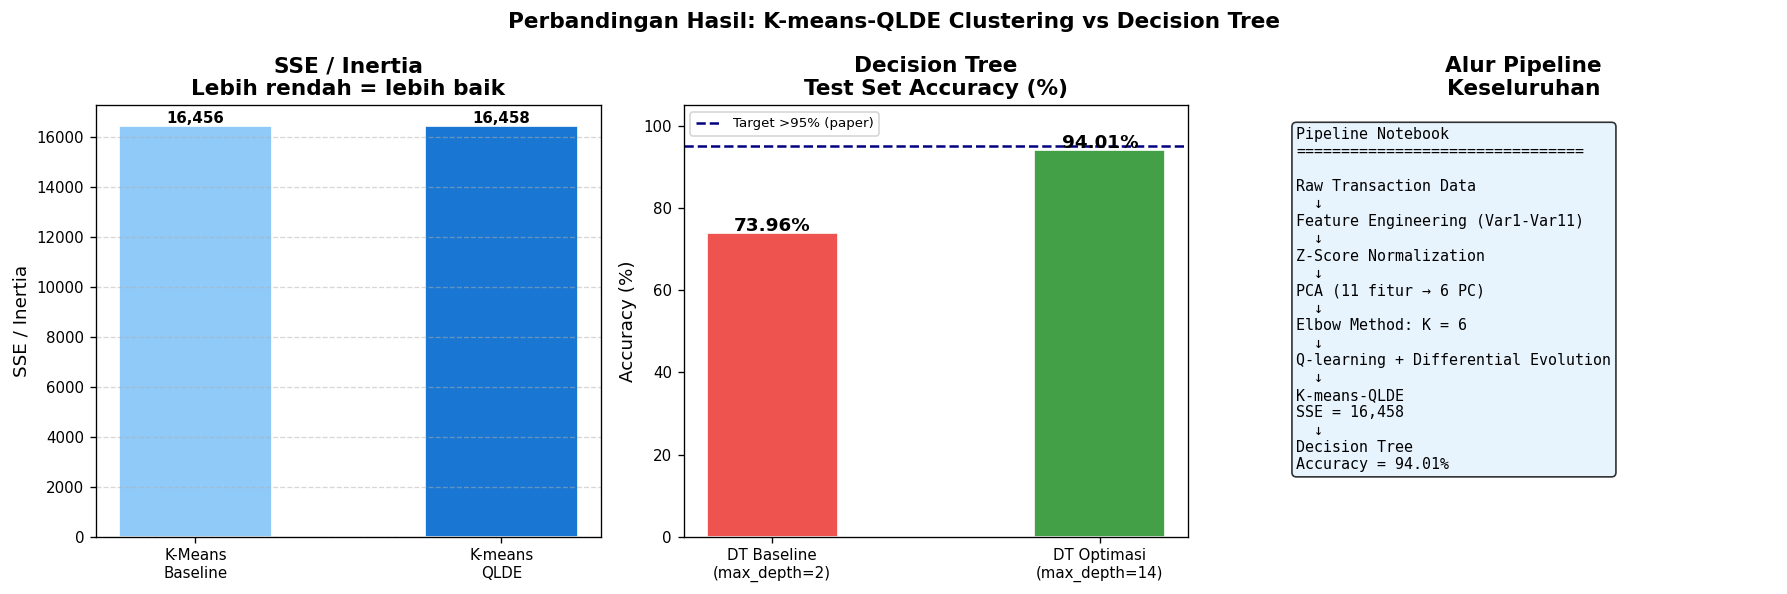

Visualisasi komparasi tersimpan.


In [43]:
# -----------------------------------------------------------
# 8.1  Visualisasi Komparasi: K-means-QLDE Metrics & DT Accuracy
# -----------------------------------------------------------

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Plot 1: SSE comparison
sse_labels = ['K-Means\nBaseline', 'K-means\nQLDE']
sse_values_plot = [kmeans_baseline.inertia_, kmeans_final.inertia_]
bars0 = axes[0].bar(sse_labels, sse_values_plot, color=['#90CAF9', '#1976D2'], width=0.5, edgecolor='white')
axes[0].set_title('SSE / Inertia\nLebih rendah = lebih baik', fontweight='bold')
axes[0].set_ylabel('SSE / Inertia')
axes[0].grid(axis='y', linestyle='--', alpha=0.5)
for bar, val in zip(bars0, sse_values_plot):
    axes[0].text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height(),
        f'{val:,.0f}',
        ha='center',
        va='bottom',
        fontsize=9,
        fontweight='bold'
    )

# Plot 2: Decision Tree Accuracy Comparison
dt_labels = [
    'DT Baseline\n(max_depth=2)',
    f'DT Optimasi\n(max_depth={best_depth})'
]
dt_accs = [BASELINE_TEST_ACC * 100, test_acc * 100]
dt_colors = ['#EF5350', '#43A047']
bars1 = axes[1].bar(dt_labels, dt_accs, color=dt_colors, edgecolor='white', width=0.4)
axes[1].axhline(y=95, color='navy', linestyle='--', linewidth=1.5, label='Target >95% (paper)')
axes[1].set_ylim([0, 105])
axes[1].set_title('Decision Tree\nTest Set Accuracy (%)', fontweight='bold')
axes[1].set_ylabel('Accuracy (%)')
axes[1].legend(fontsize=8)
for bar, val in zip(bars1, dt_accs):
    axes[1].text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 0.5,
        f'{val:.2f}%',
        ha='center',
        fontsize=11,
        fontweight='bold'
    )

# Plot 3: Pipeline
axes[2].axis('off')
pipeline_text = (
    'Pipeline Notebook\n'
    '================================\n\n'
    'Raw Transaction Data\n'
    '  ↓\n'
    'Feature Engineering (Var1-Var11)\n'
    '  ↓\n'
    'Z-Score Normalization\n'
    '  ↓\n'
    'PCA (11 fitur → 6 PC)\n'
    '  ↓\n'
    f'Elbow Method: K = {K_OPTIMAL}\n'
    '  ↓\n'
    'Q-learning + Differential Evolution\n'
    '  ↓\n'
    f'K-means-QLDE\nSSE = {kmeans_final.inertia_:,.0f}\n'
    '  ↓\n'
    f'Decision Tree\nAccuracy = {test_acc*100:.2f}%'
)
axes[2].text(
    0.05,
    0.95,
    pipeline_text,
    transform=axes[2].transAxes,
    fontsize=9,
    verticalalignment='top',
    fontfamily='monospace',
    bbox=dict(boxstyle='round', facecolor='#E3F2FD', alpha=0.8)
)
axes[2].set_title('Alur Pipeline\nKeseluruhan', fontweight='bold')

plt.suptitle('Perbandingan Hasil: K-means-QLDE Clustering vs Decision Tree',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('komparasi_qlde_dt.png', dpi=120, bbox_inches='tight')
plt.show()
print('Visualisasi komparasi tersimpan.')
